### Diagnóstico de Saneamento Financeiro e Inteligência de Vendas: Case LH Nautical 2026.

Contexto do Desafio:

Este notebook apresenta a análise profunda dos dados da LH Nautical, focando na identificação de gargalos financeiros, comportamento de estoque do Motor Yamaha 155HP e a implementação de um motor de recomendação para alavancar o faturamento através de cross-selling.



### Análise do Dataset - Descrição

👥 Clientes <br><br>

`full_name` – Nome completo do cliente

`location` – Localização (cidade/estado)

`code` – Identificador único

`email` – Endereço de e-mail

<br><br> 💳 💰 Custos <br><br>

`product_id` – Identificador do produto

`product_name` – Nome do produto

`category` – Categoria do item

`historic_data` – Histórico de preços (valores em USD ao longo do tempo).


<br><br> 📦 Produtos <br><br>


`name` – Nome do produto

`price` – Preço do produto

`code` – Identificador do produto

`actual_category` – Categoria atual


<br><br>⏳ 🛒 Vendas <br><br>


`id` – Identificador único da transação

`id_client` – Identificador do cliente

`id_product` – Identificador do produto

`qtd` – Quantidade de itens vendidos

`total` – Valor total da venda

`sale_date` – Data da venda



## Importação de Bibliotecas

In [158]:
# --- BIBLIOTECAS DE MANIPULAÇÃO DE DADOS
import json
import pandas as pd
import numpy as np

# --- TRATAMENTO DE TEXTO E DATAS (ETL) ---
import unicodedata
from datetime import datetime
import re

# --- INTEGRAÇÃO E COLETA DE DADOS ---
import requests

# --- VISUALIZAÇÃO E DESIGN DE GRÁFICOS ---
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px

# --- MODELAGEM E ANÁLISE AVANÇADA ---
from sklearn.metrics.pairwise import cosine_similarity

# Carregamento do Dataset

In [159]:
with open('/content/clientes_crm.json', 'r') as file:
    clientes_data = json.load(file)
clientes = pd.DataFrame(clientes_data)

with open('/content/custos_importacao.json', 'r') as file:
    custos_data = json.load(file)
custos = pd.DataFrame(custos_data)

produtos = pd.read_csv('/content/produtos_raw.csv', encoding='utf-8')
vendas = pd.read_csv('/content/vendas_2023_2024.csv')

# Base de Dados _ Produtos

In [161]:
produtos.head()

,name,price,code,actual_category
0,Transponder AIS Maré Magnum,R$ 33122.52,1,ELETRONICOS
1,Transponder Furuno Marlin,R$ 13998.15,2,ELETRONICOS
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,E L E T R Ô N I C O S
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,Eletrunicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,Eletronicoz


In [162]:
produtos.info()
produtos.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   name             157 non-null    object
 1   price            157 non-null    object
 2   code             157 non-null    int64 
 3   actual_category  157 non-null    object
dtypes: int64(1), object(3)
memory usage: 5.0+ KB


,code
count,157.000000
mean,76.210191
std,43.522766
min,1.000000
25%,39.000000
50%,75.000000
75%,114.000000
max,150.000000


In [163]:
# renomeando o nome das tabelas
produtos = produtos = produtos.rename(columns={
    'name': 'nome_produto' ,
    'price': 'preco',
    'code': 'id_produto',
    'actual_category': 'categoria'
})

In [164]:
# Nome das colunas
produtos.columns

Index(['nome_produto', 'preco', 'id_produto', 'categoria'], dtype='object')

In [165]:
produtos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   nome_produto  157 non-null    object
 1   preco         157 non-null    object
 2   id_produto    157 non-null    int64 
 3   categoria     157 non-null    object
dtypes: int64(1), object(3)
memory usage: 5.0+ KB


In [166]:
# Total de linhas e colunas
produtos.shape

(157, 4)

In [167]:
produtos.nunique()

,0
nome_produto,150
preco,150
id_produto,150
categoria,39


In [168]:
(produtos.isnull().sum())

,0
nome_produto,0
preco,0
id_produto,0
categoria,0


In [169]:
(produtos.duplicated().sum())

np.int64(0)

In [170]:
total_duplicados = produtos['id_produto'].duplicated().sum()
print(f"Total de IDs duplicados: {total_duplicados}")

Total de IDs duplicados: 7


In [171]:
# Filtro na tabela para mostrar apenas as linhas onde o ID se repete
duplicados_detalhe = produtos[produtos['id_produto'].duplicated(keep=False)]

# Ordenando para que os IDs iguais fiquem juntos na visualização
display(duplicados_detalhe.sort_values(by='id_produto'))

,nome_produto,preco,id_produto,categoria
36,GPS Lowrance Evo Storm Drift,R$ 6067.71,37,E L E T R Ô N I C O S
37,GPS Lowrance Evo Storm Drift,R$ 6067.71,37,ELEtRÔNICOS
62,Motor Diesel Yanmar Velocity 37HP,R$ 102221.97,62,P R O P U L S Ã O
63,Motor Diesel Yanmar Velocity 37HP,R$ 102221.97,62,Propução
64,Motor Diesel Yanmar Velocity 37HP,R$ 102221.97,62,propulsão
65,Motor Diesel Yanmar Velocity 37HP,R$ 102221.97,62,Prop
131,Cabo de Nylon Delta Velocity Core Mako,R$ 1549.35,127,Encoragem
132,Cabo de Nylon Delta Velocity Core Mako,R$ 1549.35,127,Encoragi
124,Boia de Arqueamento Delta Nexus,R$ 4349.86,145,AncorageM
150,Boia de Arqueamento Delta Nexus,R$ 4349.86,145,AncorajeM


In [172]:
print(produtos['categoria'].unique())

['ELETRONICOS' 'E L E T R Ô N I C O S' 'Eletrunicos' 'Eletronicoz'
 'eLeTrÔnIcOs' 'eletrônicos' 'Eletrônicos' 'Eletroniscos' 'Eletronicos'
 'eletronicos' 'EletrônicoS' 'ELEtRÔNICOS' 'PROPULSAO' 'Propulção' 'Prop'
 'Propulssão' 'propulsao' 'P R O P U L S Ã O' 'Propução' 'propulsão'
 'pRoPuLsÃo' 'Propulçao' 'Propulsam' 'PrOpUlSãO' 'Ancoragem' 'AnCoRaGeM'
 'Encoragem' 'Ancoraguem' 'Ancorajm' 'AncorageM' 'A N C O R A G E M'
 'ANCORAGEM' 'aNcOrAgEm' 'Ancorajem' 'Encoragi' 'ancoragem' 'Ancorajen'
 'AncorajeM' 'Ancoragen']


RESUMO DA BASE DE DADOS - PRODUTOS_RAW.CSV

A base de dados produtos_raw.csv possui 157 registros e 4 variáveis, contendo informações de: identificação, nome, preço e categoria.

Apesar de não apresentar valores nulos, ela apresenta problemas críticos de padronização na coluna 'actual_category', e encoding nos nomes dos produtos, indicando inconsistência na leitura do arquivo, idetifiquei 7 IDs duplicados, devido a variações de texto na escrita das categorias.

Os principal erro identificado envolve inconsistência textual, típicos de ausência de governança de dados.

Isso nos revela que, a empresa não possui padronização de cadastro de produtos e não há validação de entrada de dados

TRATAMENTO DA BASE DE DADOS _ TABELA PRODUTOS

In [173]:
#  Função de limpeza prara remover espaços internos e acentos (Coluna categoria)
def limpar_texto_ia(texto):
    if not isinstance(texto, str): return str(texto)
    # Tira acentos
    nfkd = unicodedata.normalize('NFKD', texto)
    texto = "".join([c for c in nfkd if not unicodedata.combining(c)])
    # Tira todos os espaços e deixa minúsculo
    return texto.lower().replace(" ", "").strip()

In [174]:
# Função de decisão (Mapeamento)
def definir_categoria_final(cat):
    c = limpar_texto_ia(cat)
    if 'elet' in c: return 'eletrônicos'
    if 'prop' in c or 'pru' in c: return 'propulsão' # 'pru' pega erros como 'propução'
    if 'ancor' in c or 'encor' in c: return 'ancoragem'
    return 'Outros'

In [175]:
# Aplicando a lógica
produtos['categoria_final'] = produtos['categoria'].apply(definir_categoria_final)

In [176]:
print("Categorias únicas após limpeza:")
print(produtos['categoria_final'].unique())

Categorias únicas após limpeza:
['eletrônicos' 'propulsão' 'ancoragem']


In [177]:
# Removendo a coluna antiga ('actual_category')
if 'categoria' in produtos.columns:
    produtos = produtos.drop(columns=['categoria'])

In [178]:
# Deduplicação: Remove IDs duplicados mantendo apenas a primeira ocorrência de cada produto
produtos = produtos.sort_values('id_produto').drop_duplicates(subset='id_produto', keep='first').copy()

In [179]:
# Garante que o id do produto seja número para evitar conflito (ex: 37 vs "37")
produtos['id_produto'] = pd.to_numeric(produtos['id_produto'], errors='coerce')

# Ordenado para manter a consistência e removemos as duplicatas em uma linha só
produtos = produtos.sort_values('id_produto').drop_duplicates(subset='id_produto', keep='first').copy()

# Reorganiza os números das linhas de 0 a 149, eliminando os "buracos"
produtos = produtos.reset_index(drop=True)

# VALIDAÇÃO
print(f"IDs únicos na tabela final: {produtos['id_produto'].nunique()}")
print(f"Total de linhas na tabela final: {len(produtos)}")
print(f"A coluna 'id_produto' é 100% única? {produtos['id_produto'].is_unique}")

IDs únicos na tabela final: 150
Total de linhas na tabela final: 150
A coluna 'id_produto' é 100% única? True


In [180]:
# 1. Calculando a diferença
total_antes = 157  # valor da tabela original
total_depois = len(produtos)
duplicados_removidos = total_antes - total_depois

# 2. Exibindo o resultado formatado
print(f" Total de registros originais: {total_antes}")
print(f" Total de produtos únicos (Pós-ETL): {total_depois}")
print(f" Duplicados removidos: {duplicados_removidos}")

 Total de registros originais: 157
 Total de produtos únicos (Pós-ETL): 150
 Duplicados removidos: 7


In [181]:
# Limpeza e Conversão da coluna 'preco' para tipo float
produtos['preco'] = (
    produtos['preco']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace(' ', '', regex=False)
    .str.strip()
)

#Transforma em Número (Float)
produtos['preco'] = pd.to_numeric(produtos['preco'], errors='coerce')

# Verificação de Sucesso (O que o Gabriel/Tech Lead validaria)
print(f"Tipo da coluna 'preco': {produtos['preco'].dtype}")
print("Exemplo de valor convertido:", produtos['preco'].iloc[0])

Tipo da coluna 'preco': float64
Exemplo de valor convertido: 33122.52


🛠️ Etapa de ETL e Qualidade de Dados

Realizado o tratamento e saneamento da tabela de produtos, para garantir a integridade das análises de faturamento. As principais ações foram:



*   Padronização de Categorias: aplicação de função de limpeza para remoção de acentos e espaços extras, consolidando o portfólio em três categorias principais: eletrônicos, propulsão e ancoragem;


*   Deduplicação de Registros: identificação e remoção de 7 IDs duplicados através da coluna code. Esta etapa é crítica para evitar a inflação artificial do faturamento no cruzamento com a tabela de vendas;

*   Tipagem e Estrutura: Conversão da coluna price para o formato numérico (float) e renomeação das colunas para facilitar a manipulação e clareza do código.

Resultado: Base de dados íntegra e pronta para o modelo de análise (Merge).

 📊 Análise Exploratória e Visualização de Dados (EDA)

In [182]:
# Garante que a coluna de categoria esteja nomeada como 'categoria' para uso nos gráficos e análises subsequentes.
# Se 'categoria_final' existe e 'categoria' não, renomeia 'categoria_final' para 'categoria'.
if 'categoria_final' in produtos.columns and 'categoria' not in produtos.columns:
    produtos = produtos.rename(columns={'categoria_final': 'categoria'})

# Verificação real dos números por categoria
print("Contagem Real por Categoria:")
print(produtos['categoria'].value_counts())

# Verificação de IDs únicos dentro de cada categoria
print("\nIDs únicos por Categoria:")
print(produtos.groupby('categoria')['id_produto'].nunique())


# 3. Verifica a soma de preços (Sinal de que os dados são diferentes)
print("\n💰 SOMA DE PREÇOS POR CATEGORIA:")
print(produtos.groupby('categoria')['preco'].sum())

Contagem Real por Categoria:
categoria
eletrônicos    50
propulsão      50
ancoragem      50
Name: count, dtype: int64

IDs únicos por Categoria:
categoria
ancoragem      50
eletrônicos    50
propulsão      50
Name: id_produto, dtype: int64

💰 SOMA DE PREÇOS POR CATEGORIA:
categoria
ancoragem       133199.82
eletrônicos     896247.63
propulsão      4173125.59
Name: preco, dtype: float64


O catálogo apresenta em termos de quantidade, com 50 itens para cada categoria (Eletrônicos, Propulsão e Ancoragem).

/tmp/ipykernel_16187/3706654210.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=produtos, x='categoria', palette=cores_nautical, order=produtos['categoria'].value_counts().index)


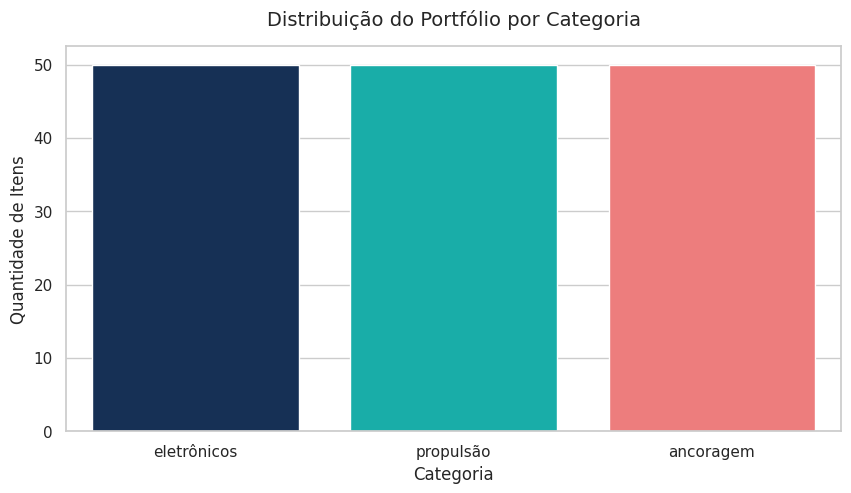

/tmp/ipykernel_16187/3706654210.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=produtos, x='categoria', y='preco', palette=cores_nautical)


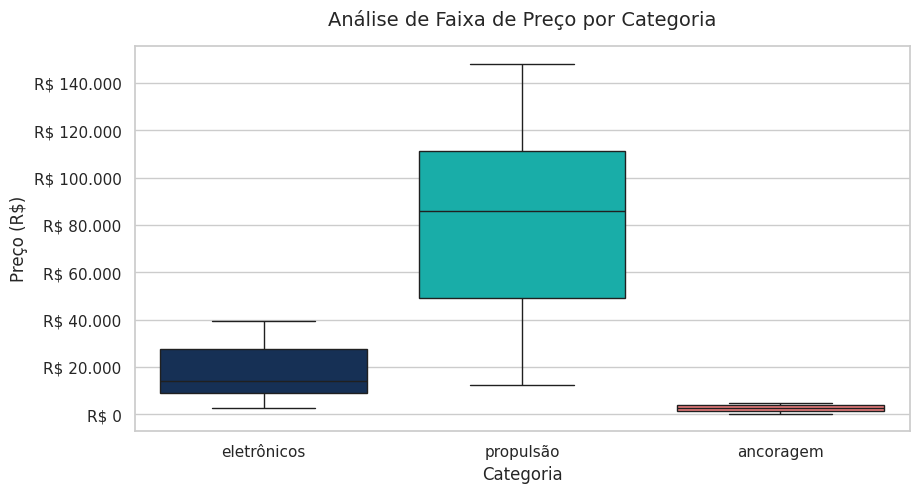

/tmp/ipykernel_16187/3706654210.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_caros, x='preco', y='nome_produto', palette="viridis")


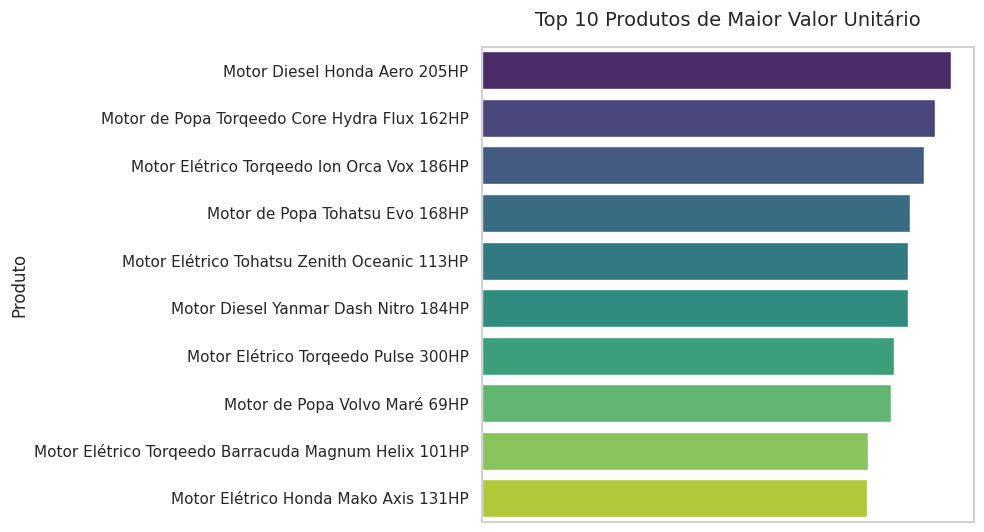

In [183]:
# Configuração visual padrão
sns.set_theme(style="whitegrid")
cores_nautical = ["#0B2F5F", "#00c6bf", "#FF6B6B"]

# --- GRÁFICO 1: MIX DE PRODUTOS POR CATEGORIA ---
plt.figure(figsize=(10, 5))
sns.countplot(data=produtos, x='categoria', palette=cores_nautical, order=produtos['categoria'].value_counts().index)
plt.title('Distribuição do Portfólio por Categoria', fontsize=14, pad=15)
plt.ylabel('Quantidade de Itens')
plt.xlabel('Categoria')
plt.show()

# --- GRÁFICO 2: DISPERSÃO DE PREÇOS (BOXPLOT) ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=produtos, x='categoria', y='preco', palette=cores_nautical)
plt.title('Análise de Faixa de Preço por Categoria', fontsize=14, pad=15)
plt.ylabel('Preço (R$)')
plt.xlabel('Categoria')
# Ajuste para formato de moeda no eixo Y
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x:,.0f}'.replace(',', '.')))
plt.show()

# --- GRÁFICO 3: TOP 10 PRODUTOS (VALOR AGREGADO) ---
top_10_caros = produtos.sort_values('preco', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_caros, x='preco', y='nome_produto', palette="viridis")
plt.title('Top 10 Produtos de Maior Valor Unitário', fontsize=14, pad=15)
plt.xlabel('Preço de Tabela (R$)')
plt.ylabel('Produto')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x:,.0f}'.replace(',', '.')))
plt.tight_layout()
plt.gca().xaxis.set_visible(False)
plt.show()

A análise conjunta dos três gráficos revela um catálogo de produtos estrategicamente equilibrado em variedade, mas taticamente concentrado em valor.


*   A empresa mantém uma distribuição igualitária de 50 itens para cada uma das três categorias (Eletrônicos, Propulsão e Ancoragem).

*  Apesar do equilíbrio em quantidade, a categoria de Propulsão é o verdadeiro motor financeiro do portfólio, apresentando a maior valorização média e a maior amplitude de preços.

# Base de Dados _ Clientes

In [184]:
clientes.head()

,full_name,location,code,email
0,Femininos Oliveira Antunes,"Aratu (Candeias) , BA",1,femininos.oliveira.antunes@icloud.com
1,Fernanda Azevedo Soares Nunes Vieira,"PE , Recife",2,nunes.fernanda.soares.azevedo.vieira@outlook.com
2,Daniel Farias Ribeiro Teixeira,"Rio Grande,RS",3,farias.teixeira.daniel.ribeiro#gmail.com
3,Thiago Moreira,"AC , Rio Branco",4,thiago.moreira#gmail.com
4,Pedro Freitas,PA - Santarém Novo,5,pedro.freitas#icloud.com


In [185]:
clientes.info()
clientes.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_name  49 non-null     object
 1   location   49 non-null     object
 2   code       49 non-null     int64 
 3   email      49 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.7+ KB


,code
count,49.00000
mean,25.00000
std,14.28869
min,1.00000
25%,13.00000
50%,25.00000
75%,37.00000
max,49.00000


In [186]:
# renomeando as  colunas
clientes = clientes.rename(columns={
    'full_name': 'nome_completo',
    'code': 'id_cliente',
    'email': 'email',
    'location': 'localizacao'
})

In [187]:
clientes.columns

Index(['nome_completo', 'localizacao', 'id_cliente', 'email'], dtype='object')

In [188]:
clientes.shape

(49, 4)

In [189]:
# Contagen de valoree únivos nas colunas
clientes.nunique()

,0
nome_completo,49
localizacao,48
id_cliente,49
email,49


In [190]:
# Soma de Valores Nulos
(clientes.isnull().sum())

,0
nome_completo,0
localizacao,0
id_cliente,0
email,0


In [191]:
# Identificando IDs duplicados, para garantir que cada registro represente um cliente único e exclusivo.

clientes_duplicados = clientes[clientes.duplicated(subset=['id_cliente'], keep=False)]
clientes_duplicados = clientes_duplicados.sort_values(by='id_cliente')

print(f"Total de registros com IDs duplicados: {len(clientes_duplicados)}")
display(clientes_duplicados.head(10))

Total de registros com IDs duplicados: 0


,nome_completo,localizacao,id_cliente,email


In [192]:
(clientes.duplicated().sum())

np.int64(0)

**Resumo**

A base de clientes possui 49 registros e 4 variáveis, contendo informações básicas como: nome, localização, código identificador e e-mail.

Apesar de não apresentar valores nulos, nem duplicidade de IDs, foram identificados problemas relevantes de padronização e qualidade dos dados, que podem impactar análises futuras e integrações com outras bases.

Problemas:

*   Localização inconsistente: formatos diferentes (vírgula, hífen, ordem invertida),  o que dificulta análise por estado/cidade
*   E-mails inválidos: o uso de # no lugar de @, é possível que a empresa não possua validação de cadastro no CRM


TRATAMENTO DA TABELA CLIENTES

In [193]:
# 1. Corrigindo o caractere especial nos e-mails (# para @)
clientes['email'] = clientes['email'].str.replace('#', '@', regex=False)

# 2. Limpando os nomes (Removendo espaços extras e padronizando iniciais maiúsculas)
clientes['nome_completo'] = clientes['nome_completo'].str.strip().str.title()

# 3. Visualizando o "Antes e Depois" clínico
display(clientes[['nome_completo', 'email']].head())

,nome_completo,email
0,Femininos Oliveira Antunes,femininos.oliveira.antunes@icloud.com
1,Fernanda Azevedo Soares Nunes Vieira,nunes.fernanda.soares.azevedo.vieira@outlook.com
2,Daniel Farias Ribeiro Teixeira,farias.teixeira.daniel.ribeiro@gmail.com
3,Thiago Moreira,thiago.moreira@gmail.com
4,Pedro Freitas,pedro.freitas@icloud.com


In [194]:
def extrair_uf_cidade_corrigido(texto):
    # 1. Mantém sua lógica de separar por traço ou barra
    partes = [p.strip() for p in re.split(r'[|\-,]', texto)]

    # 2. Identifica a UF (2 letras)
    uf = next((p for p in partes if len(p) == 2), "N/A")

    # 3. Identifica a Cidade (mais de 2 letras)
    cidade_bruta = next((p for p in partes if len(p) > 2), "N/A")

    # --- O PULO DO GATO ---
    # Se a cidade tiver parênteses, vamos pegar só o que está dentro deles
    match_parenteses = re.search(r'\((.*?)\)', cidade_bruta)
    if match_parenteses:
        cidade_final = match_parenteses.group(1).strip()
    else:
        cidade_final = cidade_bruta

    return pd.Series([cidade_final.title(), uf.upper()])

# APLICAÇÃO:
clientes[['Cidade', 'Estado']] = clientes['localizacao'].apply(extrair_uf_cidade_corrigido)

# O restante do seu código (Passo 4 e 5) você MANTEÉM igual:
clientes_final = clientes.drop(columns=['localizacao']) # Removi loc_temp pois não precisamos mais
display(clientes_final.head())

,nome_completo,id_cliente,email,Cidade,Estado
0,Femininos Oliveira Antunes,1,femininos.oliveira.antunes@icloud.com,Candeias,BA
1,Fernanda Azevedo Soares Nunes Vieira,2,nunes.fernanda.soares.azevedo.vieira@outlook.com,Recife,PE
2,Daniel Farias Ribeiro Teixeira,3,farias.teixeira.daniel.ribeiro@gmail.com,Rio Grande,RS
3,Thiago Moreira,4,thiago.moreira@gmail.com,Rio Branco,AC
4,Pedro Freitas,5,pedro.freitas@icloud.com,Santarém Novo,PA


In [195]:
def separar_cidade_estado_final(loc):
    if pd.isna(loc):
        return pd.Series([None, None])

    loc = loc.strip()

    # Buscar estado (sigla com 2 letras maiúsculas)
    match = re.search(r'([A-Z]{2})', loc)
    estado = match.group(1) if match else None

    # Extrair cidade:
    # 1. se houver parênteses, pegar o conteúdo dentro deles
    par = re.search(r'\((.*?)\)', loc)
    if par:
        cidade = par.group(1)
    else:
        # caso não tenha parênteses, remover siglas e símbolos no início e final
        cidade = loc
        if estado:
            cidade = re.sub(r'[,/-]?\s*' + estado + r'$', '', cidade)
        cidade = re.sub(r'^[A-Z]{2}\s*[-/,]\s*', '', cidade)

    # Padronizar nome
    cidade = cidade.strip().title()

    return pd.Series([cidade if cidade != '' else None, estado])

# Aplicar função
clientes[['cidade', 'estado']] = clientes['localizacao'].apply(separar_cidade_estado_final)

# Visualizar os primeiros registros
display(clientes[['localizacao', 'cidade', 'estado']].head(10))

,localizacao,cidade,estado
0,"Aratu (Candeias) , BA",Candeias,BA
1,"PE , Recife",Recife,PE
2,"Rio Grande,RS",Rio Grande,RS
3,"AC , Rio Branco",Rio Branco,AC
4,PA - Santarém Novo,Santarém Novo,PA
5,"Fortaleza do Tabocão , TO",Fortaleza Do Tabocão,TO
6,PB/Cabedelo,Cabedelo,PB
7,SE - Aracaju,Aracaju,SE
8,PB - João Pessoa,João Pessoa,PB
9,Santarém / PA,Santarém,PA


In [196]:
# Dropar colunas desnecessárias
colunas_para_remover = ['localizacao', 'loc_temp', 'Estado', 'Cidade', 'email_valido']
clientes = clientes.drop(columns=[c for c in colunas_para_remover if c in clientes.columns])

In [197]:
# Reordenar colunas
colunas_ordenadas = ['id_cliente', 'nome_completo', 'email', 'cidade', 'estado']
clientes = clientes[colunas_ordenadas]

In [198]:
clientes.columns

Index(['id_cliente', 'nome_completo', 'email', 'cidade', 'estado'], dtype='object')

In [199]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id_cliente     49 non-null     int64 
 1   nome_completo  49 non-null     object
 2   email          49 non-null     object
 3   cidade         49 non-null     object
 4   estado         49 non-null     object
dtypes: int64(1), object(4)
memory usage: 2.0+ KB


 📊 Análise Exploratória e Visualização de Dados (EDA)

In [227]:
# fazendo merge das tabelas

df_vendas_prod = vendas.merge(
    produtos[['id_produto', 'categoria']],
    on='id_produto',
    how='left'
)

df_vendas_prod[['id_cliente', 'id_produto', 'categoria']].head()

,id_cliente,id_produto,categoria
0,42,105,ancoragem
1,3,136,ancoragem
2,25,139,ancoragem
3,20,23,eletrônicos
4,8,57,propulsão


In [228]:
# Faturamento Total + Ticket médio + frequencia + diversidade_categorias

df_clientes = df_vendas_prod.groupby('id_cliente').agg(
    faturamento_total=('valor_total', 'sum'),
    frequencia=('id_venda', 'count'),
    diversidade_categorias=('categoria', 'nunique')
).reset_index()

# ticket médio
df_clientes['ticket_medio'] = (
    df_clientes['faturamento_total'] / df_clientes['frequencia']
)

df_clientes.head()

,id_cliente,faturamento_total,frequencia,diversidade_categorias,ticket_medio
0,1,51092500.05,190,3,268907.895000
1,2,65652931.35,220,3,298422.415227
2,3,59575349.10,207,3,287803.618841
3,4,50691754.40,207,3,244887.702415
4,5,58592802.70,202,3,290063.379703


In [229]:
df_clientes['diversidade_categorias'].value_counts()

,count
diversidade_categorias,
3,49


In [230]:
# Clientes que compraram produtos de 3 ou mais categorias

df_elite = df_clientes[df_clientes['diversidade_categorias'] >= 3]
df_elite.head()

,id_cliente,faturamento_total,frequencia,diversidade_categorias,ticket_medio
0,1,51092500.05,190,3,268907.895000
1,2,65652931.35,220,3,298422.415227
2,3,59575349.10,207,3,287803.618841
3,4,50691754.40,207,3,244887.702415
4,5,58592802.70,202,3,290063.379703


In [231]:
# Top 10 clientes com maior Ticket Médio que possuem diversidade ce categoria >=3

top_10_clientes = df_elite.sort_values(
    by=['ticket_medio', 'id_cliente'],
    ascending=[False, True]
).head(10)

top_10_clientes

,id_cliente,faturamento_total,frequencia,diversidade_categorias,ticket_medio
46,47,64003343.75,190,3,336859.703947
41,42,72187369.50,222,3,325168.331081
8,9,66788855.35,218,3,306370.896101
21,22,59581398.75,198,3,300916.155303
1,2,65652931.35,220,3,298422.415227
27,28,60826837.25,204,3,298170.770833
45,46,59126834.35,199,3,297119.770603
37,38,57093331.15,195,3,292786.313590
35,36,62791038.15,215,3,292051.340233
4,5,58592802.70,202,3,290063.379703


In [232]:
# Categoria mais comprada pelos top 10 clientes com maior Ticket Médio e que possuem diversidade ce categoria >=3

# pegar só vendas dos top 10 clientes
vendas_top10 = df_vendas_prod[
    df_vendas_prod['id_cliente'].isin(top_10_clientes['id_cliente'])
]

# somar quantidade por categoria
categoria_top10 = vendas_top10.groupby('categoria').agg(
    total_itens=('quantidade', 'sum')
).reset_index()

# categoria com maior quantidade
categoria_mais_comprada = categoria_top10.sort_values(
    by='total_itens',
    ascending=False
).head(1)

categoria_mais_comprada

,categoria,total_itens
2,propulsão,6030


/tmp/ipykernel_16187/449389093.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot_ticket = sns.barplot(


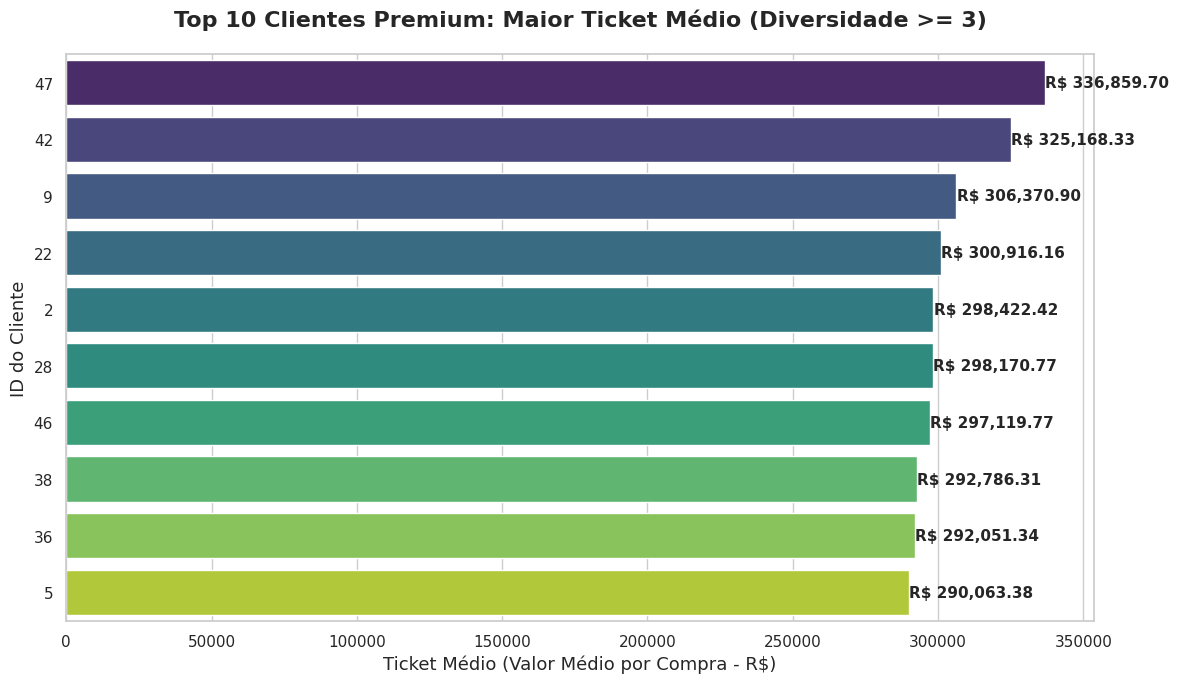

In [233]:
# Gráfico do Top 10 clientes com maior Ticket Médio e que possuem diversidade ce categoria >=3


# 1. Configuração Visual do Gráfico
plt.figure(figsize=(12, 7)) # Aumentei um pouco a altura para acomodar 10 barras
sns.set_style("whitegrid")


# Usando o 'id_cliente' no eixo Y para as barras ficarem deitadas
plot_ticket = sns.barplot(
    data=top_10_clientes,
    x='ticket_medio',
    y=top_10_clientes['id_cliente'].astype(str), # Converte ID para texto para garantir o eixo Y correto
    palette='viridis', # Uma paleta de cores profissional e bonita
    orient='h' # Garante a orientação horizontal
)


plt.title('Top 10 Clientes Premium: Maior Ticket Médio (Diversidade >= 3)',
          fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Ticket Médio (Valor Médio por Compra - R$)', fontsize=13)
plt.ylabel('ID do Cliente', fontsize=13)

for i, v in enumerate(top_10_clientes['ticket_medio']):
    plt.text(v + 100, i, f'R$ {v:,.2f}', va='center', fontweight='bold', fontsize=11)


plt.tight_layout()
plt.show()

In [234]:
# Lista do nome dos Top 10 com maior Ticket Médio e que possuem diversidade ce categoria >=3

# Mesclar top_10_clientes com o DataFrame clientes para obter 'nome_completo'
df_nomes_top10 = pd.merge(
    top_10_clientes[['id_cliente', 'ticket_medio', 'diversidade_categorias']],
    clientes[['id_cliente', 'nome_completo']],
    on='id_cliente',
    how='left'
)

# Renomear 'nome_completo' para 'nome_cliente' para manter a consistência com o nome original da coluna esperada
df_nomes_top10 = df_nomes_top10.rename(columns={'nome_completo': 'nome_cliente'})

# 2. Reorganizar as colunas para a leitura ficar mais natural
df_nomes_top10 = df_nomes_top10[['id_cliente', 'nome_cliente', 'ticket_medio', 'diversidade_categorias']]

# 3. Exibir a tabela formatada
print("--- Tabela Nominal: Top 10 Clientes (Maior Ticket Médio) ---")
display(df_nomes_top10)

--- Tabela Nominal: Top 10 Clientes (Maior Ticket Médio) ---


,id_cliente,nome_cliente,ticket_medio,diversidade_categorias
0,47,Gabriela Barros Lacerda,336859.703947,3
1,42,Márcia Figueiredo,325168.331081,3
2,9,Lucas Guedes Cunha Lopes,306370.896101,3
3,22,Daniela Borges Vieira Farias Mendonça,300916.155303,3
4,2,Fernanda Azevedo Soares Nunes Vieira,298422.415227,3
5,28,Bianca Rodrigues,298170.770833,3
6,46,Ana Silva Costa Farias Coelho,297119.770603,3
7,38,Mateus Antunes,292786.313590,3
8,36,Francisca Ribeiro Pinheiro,292051.340233,3
9,5,Pedro Freitas,290063.379703,3


A análise identificou o Top 10 clientes mais fiéis e estratégicos da LH Nautical, considerando não apenas o valor gasto por transação, mas também a diversidade de categorias adquiridas (=>3)

Critérios de seleção:

*   Compraram produtos de 3 iu mais categorias distintas.
*   Possuem ticket médio elevado (gasto médio por transação).

Não foram identificados empate

Principais insights:


*  Top 10 clientes Premium: representam os consumidores com maior impacto financeiro;
*   Categoria mais consumida: entre os clientes Premium, a categoria propulsão concentrou a maior quantidade de itens comprados;
*   Comportamento de consumo: clientes elite não compram apenas muito de um único tipo de produto; eles exploram diferentes categorias, mostrando potencial de replicação desse padrão em outros segmentos.


Recomendações estratégicas:

Focar em campanhas e ofertas para clientes com múltiplas categorias de interesse.

Analisar o perfil de compra da categoria predominante (propulsão) para produtos relacionados.

Utilizar esses clientes como referência para programas de fidelidade e estratégias de marketing premium.

In [143]:
#Dia da Semana que apresenta a menor média de vendas histórica

# 1 Criar calendário completo do período
calendario = pd.DataFrame({
    'data': pd.date_range(start=vendas['data_venda'].min(),
                          end=vendas['data_venda'].max())
})

# 2 Adicionar dia da semana em português
dias_pt = {0:'Segunda-feira', 1:'Terça-feira', 2:'Quarta-feira',
           3:'Quinta-feira', 4:'Sexta-feira', 5:'Sábado', 6:'Domingo'}
calendario['dia_semana'] = calendario['data'].dt.dayofweek.map(dias_pt)

# 3 Agrupar vendas por data
vendas_diarias = vendas.groupby('data_venda', as_index=False)['valor_total'].sum()

# 4️ Fazer merge do calendário com vendas, preenchendo NaN com 0
df_merge = calendario.merge(vendas_diarias, left_on='data', right_on='data_venda', how='left')
df_merge['valor_total'] = df_merge['valor_total'].fillna(0)

# 5️ Agrupar por dia da semana e calcular média
media_dia_semana = df_merge.groupby('dia_semana')['valor_total'].mean().round(2).reset_index()

# 6️ Ordenar para identificar o dia com menor média
media_dia_semana = media_dia_semana.sort_values('valor_total')

# Define 'menor_media' by selecting the first row after sorting
menor_media = media_dia_semana.iloc[0]

print(media_dia_semana)

print("Dia da semana com menor média:", menor_media['dia_semana'])
print("Média de vendas (R$):", menor_media['valor_total'])

      dia_semana  valor_total
3  Segunda-feira   3285975.58
0        Domingo   3366781.09
2   Quinta-feira   3560174.45
1   Quarta-feira   3649345.28
4    Sexta-feira   3651962.65
5         Sábado   3667602.92
6    Terça-feira   3816335.14
Dia da semana com menor média: Segunda-feira
Média de vendas (R$): 3285975.58


A analise mostrou que, segunda-feira é o dia que historicamente vende menos, com a média de vendas de R$ 3285975.58. Considerando todos os dias do calendário, inclusive aqueles sem vendas

In [144]:
# 1 Criar calendário completo do período
calendario = pd.DataFrame({
    'data': pd.date_range(start=vendas['data_venda'].min(),
                          end=vendas['data_venda'].max())
})

# 2️ Adicionar dia da semana em português
dias_pt = {0:'Segunda-feira', 1:'Terça-feira', 2:'Quarta-feira',
           3:'Quinta-feira', 4:'Sexta-feira', 5:'Sábado', 6:'Domingo'}
calendario['dia_semana'] = calendario['data'].dt.dayofweek.map(dias_pt)

# 3️ Agrupar vendas por data
vendas_diarias = vendas.groupby('data_venda', as_index=False)['valor_total'].sum()

# 4️ Merge calendário x vendas, preenchendo NaN com 0
df_merge = calendario.merge(vendas_diarias, left_on='data', right_on='data_venda', how='left')
df_merge['valor_total'] = df_merge['valor_total'].fillna(0)

# 5️ Agrupar por dia da semana e calcular média
media_dia_semana = df_merge.groupby('dia_semana')['valor_total'].mean().round(2).reset_index()

# 6️ Identificar o dia com menor média
menor_media = media_dia_semana.sort_values('valor_total').iloc[0]

print("Dia da semana com menor média:", menor_media['dia_semana'])
print("Média de vendas (R$):", menor_media['valor_total'])

Dia da semana com menor média: Segunda-feira
Média de vendas (R$): 3285975.58


# Base de Dados _ Custos

In [239]:
custos.head()

,product_id,product_name,category,historic_data
0,1,Transponder AIS Maré Magnum,eletrônicos,"[{'start_date': '10/08/2016', 'usd_price': 105..."
1,2,Transponder Furuno Marlin,eletrônicos,"[{'start_date': '23/11/2017', 'usd_price': 432..."
2,3,Radar Furuno Pulse Leviathan,eletrônicos,"[{'start_date': '12/04/2016', 'usd_price': 254..."
3,4,Rádio AIS Hydro Tidal Zen,eletrônicos,"[{'start_date': '04/03/2016', 'usd_price': 909..."
4,5,Piloto Automático Furuno Storm,eletrônicos,"[{'start_date': '10/02/2016', 'usd_price': 600..."


In [240]:
custos.columns

Index(['product_id', 'product_name', 'category', 'historic_data'], dtype='object')

**Resumo**

A base de Custos contém 150 registros e 4 variáveis, representando produtos e seus respectivos históricos de custo ao longo do tempo.

A estrutura da coluna historic_data indica um formato semi-estruturado (lista de dicionáriosaninhados). Esse formato impede o consumo direto por ferramentas de BI e precisa de um processo de ETL para "normalizar" os dados.

Problemas:

*  A Coluna historic_data não está estruturada
*  A coluna start_date está como texto (object)

Podemos perceber que, a empresa tem variação de custo ao longo do tempo, porém, a falta de estruturação desses dados indica que a LH Nautical provavelmente não consegue monitorar a margem de lucro de forma precisa quando o custo do produto ou o câmbio oscilam.

TRATAMENTO DOS DADOS

In [241]:
# Criando uma cópia para preservar o original e explodindo o JSON
custos_tb2 = custos.explode('historic_data').reset_index(drop=True)

# Verificando o resultado
print(f"Total de linhas antes da explosão do JSON: {len(custos)}")
print(f"Total de linhas após a explosão do JSON: : {len(custos_tb2)}")
display(custos_tb2.head(10))

Total de linhas antes da explosão do JSON: 150
Total de linhas após a explosão do JSON: : 1260


,product_id,product_name,category,historic_data
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '10/08/2016', 'usd_price': 1058..."
1,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '15/06/2018', 'usd_price': 8778..."
2,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '25/09/2018', 'usd_price': 8023..."
3,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '19/03/2019', 'usd_price': 8772..."
4,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '17/01/2020', 'usd_price': 7918..."
5,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '17/06/2020', 'usd_price': 6310..."
6,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '02/07/2021', 'usd_price': 6586.7}"
7,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '16/05/2022', 'usd_price': 6538.2}"
8,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '28/02/2023', 'usd_price': 6360..."
9,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '17/10/2023', 'usd_price': 6574.8}"


In [242]:
# Transformando os dicionários da coluna 'historic_data' em novas colunas
custos_colunas = pd.json_normalize(custos_tb2['historic_data'])

# Juntando essas novas colunas com a nossa tabela principal
# Vamos descartar a coluna original 'historic_data' que não serve mais
custos_final = pd.concat([custos_tb2.drop(columns=['historic_data']), custos_colunas], axis=1)

# Verificando as novas colunas
print("Novas colunas criadas:")
display(custos_final.head())
print(custos_final.info())

Novas colunas criadas:


,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,10/08/2016,10583.63
1,1,Transponder AIS Maré Magnum,eletrônicos,15/06/2018,8778.36
2,1,Transponder AIS Maré Magnum,eletrônicos,25/09/2018,8023.87
3,1,Transponder AIS Maré Magnum,eletrônicos,19/03/2019,8772.78
4,1,Transponder AIS Maré Magnum,eletrônicos,17/01/2020,7918.18


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1260 non-null   int64  
 1   product_name  1260 non-null   object 
 2   category      1260 non-null   object 
 3   start_date    1260 non-null   object 
 4   usd_price     1260 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 49.3+ KB
None


Após o processo de normalização, o dataset resultante possui 1.260 entradas de importação, representando os registros históricos de custos por produto ao longo do tempo

In [243]:
custos_final.columns

Index(['product_id', 'product_name', 'category', 'start_date', 'usd_price'], dtype='object')

In [244]:
# Renomeando as colunas da tabela

custos_final = custos_final.rename(columns={
    'product_id': 'id_produto',
    'product_name': 'nome_produto',
    'category': 'categoria',
    'start_date': 'data_vigencia_custo',
    'usd_price': 'preco_custo_usd'
})

In [245]:
custos_final.columns

Index(['id_produto', 'nome_produto', 'categoria', 'data_vigencia_custo',
       'preco_custo_usd'],
      dtype='object')

In [246]:
(custos_final.isnull().sum())

,0
id_produto,0
nome_produto,0
categoria,0
data_vigencia_custo,0
preco_custo_usd,0


In [247]:
(custos_final.isnull().sum())

,0
id_produto,0
nome_produto,0
categoria,0
data_vigencia_custo,0
preco_custo_usd,0


In [248]:
# 1. Ver apenas os nomes únicos da coluna 'categoria"
print(custos_final['categoria'].unique())

['eletrônicos' 'propulsão' 'ancoragem']


In [249]:
# Verificando IDs que se repetem
ids_duplicados = custos_final[custos_final.duplicated(subset=['id_produto'])]['id_produto'].unique()

print(f"Total de IDs com duplicatas: {len(ids_duplicados)}")

Total de IDs com duplicatas: 150


In [250]:
# Identificando duplicatas 100% idênticas no DataFrame final
duplicatas_totais = custos_final.duplicated().sum()

# Identificando se o mesmo produto tem o mesmo custo na mesma data (Conflito de Chave)
conflitos_historico = custos_final.duplicated(subset=['id_produto', 'data_vigencia_custo']).sum()

print(f" Relatório de Integridade - Tabela: Custos_importação. (JSON Explodido)")
print("-" * 50)
print(f" Total de registros após explosão: {len(custos_final)}")
print(f" Linhas 100% duplicadas: {duplicatas_totais}")
print(f" Conflitos (Mesmo ID na mesma Data): {conflitos_historico}")
print("-" * 50)

 Relatório de Integridade - Tabela: Custos_importação. (JSON Explodido)
--------------------------------------------------
 Total de registros após explosão: 1260
 Linhas 100% duplicadas: 0
 Conflitos (Mesmo ID na mesma Data): 0
--------------------------------------------------


In [251]:
# Criando a contagem de registros (frequência)

contagem_base = custos_final['id_produto'].value_counts().reset_index()
contagem_base.columns = ['id_produto', 'quantidade_de_registros']

# Criando uma tabela de referência apenas com ID e Nome (sem duplicatas)
referencia_nomes = custos_final[['id_produto', 'nome_produto']].drop_duplicates()

# Unindo a contagem com os nomes
contagem_historico = contagem_base.merge(referencia_nomes, on='id_produto', how='left')

# Reorganizando as colunas para o nome vir primeiro
contagem_historico = contagem_historico[['id_produto', 'nome_produto', 'quantidade_de_registros']]

# Mostrando os 10 produtos com mais atualizações de custo
print("📊 Top 10 Produtos com maior histórico de custos (JSON Explodido):")
display(contagem_historico.head(10))

# Resumo Estatístico
print("\n--- Resumo da Base de Custos ---")
print(f"Média de atualizações por produto: {contagem_historico['quantidade_de_registros'].mean():.1f}")
print(f"Produto com mais atualizações: {contagem_historico['quantidade_de_registros'].max()}")
print(f"Produto com menos atualizações: {contagem_historico['quantidade_de_registros'].min()}")

📊 Top 10 Produtos com maior histórico de custos (JSON Explodido):


,id_produto,nome_produto,quantidade_de_registros
0,1,Transponder AIS Maré Magnum,15
1,18,Rádio Simrad Axis,15
2,141,Boia de Arqueamento Bruce Nexus Abyss,15
3,143,Âncora Delta Hydra Kraken Velocity,15
4,51,Motor Diesel Tohatsu Evo Zenith 16HP,15
5,36,Radar Lowrance Aqua Pulse,15
6,92,Motor Elétrico Yamaha Nautic Kraken 133HP,15
7,101,Cabo de Nylon Delta Vortex,15
8,148,Âncora Delta Force Barracuda Mako,15
9,122,Corrente Danforth Zenith Oceanic Torque,15



--- Resumo da Base de Custos ---
Média de atualizações por produto: 8.4
Produto com mais atualizações: 15
Produto com menos atualizações: 3


Com base na análise de contagem, foi possível confirmar que os produtos possuem múltiplas entradas, por esse motivo o IDs se repetem. Esse comportamento é esperado, pois trata-se de uma cada repetição do id do produto, representa uma atualização no custo de aquisição do produto ao longo do tempo.

In [252]:
custos_final.describe()

,id_produto,preco_custo_usd
count,1260.000000,1260.000000
mean,75.142857,7890.234786
std,44.170461,9961.166048
min,1.000000,53.370000
25%,36.000000,843.865000
50%,75.000000,2991.195000
75%,113.000000,11807.730000
max,150.000000,48583.210000


In [253]:
# Convertendo a coluna 'data_vigencia_custo' para o formato de data padrão brasileiro (DD/MM/AAAA)

custos_final['data_vigencia_custo'] = pd.to_datetime(custos_final['data_vigencia_custo'], dayfirst=True)

print("Check-up de Tipagem Final:")
print(custos_final.dtypes)
display(custos_final[['nome_produto', 'data_vigencia_custo', 'preco_custo_usd']].head(5))

Check-up de Tipagem Final:
id_produto                      int64
nome_produto                   object
categoria                      object
data_vigencia_custo    datetime64[ns]
preco_custo_usd               float64
dtype: object


,nome_produto,data_vigencia_custo,preco_custo_usd
0,Transponder AIS Maré Magnum,2016-08-10,10583.63
1,Transponder AIS Maré Magnum,2018-06-15,8778.36
2,Transponder AIS Maré Magnum,2018-09-25,8023.87
3,Transponder AIS Maré Magnum,2019-03-19,8772.78
4,Transponder AIS Maré Magnum,2020-01-17,7918.18


ANALISE DA TABELA CUSTOS

In [254]:
# Convertendo colunas de data para o tipo datetime e cruzar a data da venda com a vigência do custo na época

vendas['data_venda'] = pd.to_datetime(vendas['data_venda'], format='mixed', errors='coerce')
custos_final['data_vigencia_custo'] = pd.to_datetime(custos_final['data_vigencia_custo'])

In [255]:
#Ordenando a base por produto e cronologia para garantir a integridade do histórico de preços

custos_final = custos_final.sort_values(['id_produto', 'data_vigencia_custo'])

In [256]:
#  Cruzamento associando cada venda ao custo unitário vigente na data da transação.

df_merge = pd.merge_asof(
    vendas.sort_values('data_venda'),
    custos_final.sort_values('data_vigencia_custo'),
    left_on='data_venda',
    right_on='data_vigencia_custo',
    left_by='id_produto',
    right_by='id_produto',
    direction='backward'
)

In [257]:
# O fato do número de linhas ser exatamente o mesmo (9895) nas duas tabelas, significa que não houve duplicidade de venda ao faze ro merge

print("Vendas:", vendas.shape)
print("Merge:", df_merge.shape)

Vendas: (9895, 10)
Merge: (9895, 14)


In [258]:
df_merge[['id_produto', 'data_venda', 'data_vigencia_custo', 'preco_custo_usd']].head(10)

,id_produto,data_venda,data_vigencia_custo,preco_custo_usd
0,44,2023-01-01,2022-01-17,1963.02
1,67,2023-01-01,2022-06-17,16720.73
2,133,2023-01-01,2022-07-06,348.47
3,130,2023-01-01,2021-03-22,749.89
4,91,2023-01-01,2022-03-16,26303.31
5,53,2023-01-01,2022-07-19,9958.63
6,15,2023-01-01,2022-12-06,5325.40
7,95,2023-01-01,2022-11-23,12945.63
8,96,2023-01-01,2022-09-30,13063.42
9,22,2023-01-01,2022-08-22,7630.67


Foi utlizada a API do Banco Central para termos a cotação do dolar  (https://api.bcb.gov.br/dados/serie/bcdata.sgs.10813/dados)

In [259]:
import pandas as pd
import requests

url = (
    "https://api.bcb.gov.br/dados/serie/bcdata.sgs.10813/dados"
    "?formato=json&dataInicial=01/01/2023&dataFinal=31/12/2024"
)

response = requests.get(url)
data = response.json()

df_cambio = pd.DataFrame(data)

df_cambio.head()

,data,valor
0,02/01/2023,5.3430
1,03/01/2023,5.3753
2,04/01/2023,5.4453
3,05/01/2023,5.4020
4,06/01/2023,5.2849


In [260]:
# Converter data
df_cambio['data'] = pd.to_datetime(df_cambio['data'], dayfirst=True)

# Converter valor para número
df_cambio['valor'] = df_cambio['valor'].astype(float)

# Renomear para padrão do projeto
df_cambio = df_cambio.rename(columns={'valor': 'cotacaoVenda'})

# Criar coluna de data sem hora (igual vendas)
df_cambio['data'] = df_cambio['data'].dt.date

df_cambio.head()

,data,cotacaoVenda
0,2023-01-02,5.3430
1,2023-01-03,5.3753
2,2023-01-04,5.4453
3,2023-01-05,5.4020
4,2023-01-06,5.2849


In [261]:
df_cambio['cotacaoVenda'] = df_cambio['cotacaoVenda'].round(2)
df_cambio.head()

,data,cotacaoVenda
0,2023-01-02,5.34
1,2023-01-03,5.38
2,2023-01-04,5.45
3,2023-01-05,5.40
4,2023-01-06,5.28


Merge câmbio com vendas

In [262]:
# Fazendo um Merge Câmbio com Vendas

df_merge['data'] = df_merge['data_venda'].dt.date

In [263]:
df_merge.columns

Index(['id_venda', 'id_cliente', 'id_produto', 'quantidade', 'valor_total',
       'data_venda', 'dia_semana', 'preco_unitario', 'ano', 'mes',
       'nome_produto', 'categoria', 'data_vigencia_custo', 'preco_custo_usd',
       'data'],
      dtype='object')

In [264]:
df_merge = df_merge.merge(
    df_cambio,
    on='data',
    how='left'
)

In [265]:
df_merge[['data_venda', 'cotacaoVenda']].head(10)

,data_venda,cotacaoVenda
0,2023-01-01,NaN
1,2023-01-01,NaN
2,2023-01-01,NaN
3,2023-01-01,NaN
4,2023-01-01,NaN
5,2023-01-01,NaN
6,2023-01-01,NaN
7,2023-01-01,NaN
8,2023-01-01,NaN
9,2023-01-01,NaN


Para datas sem cotação, foram aplicadas técnicas de forward fill e backward fill, garantindo cobertura completa da série temporal.

In [266]:
df_merge = df_merge.sort_values('data')

df_merge['cotacaoVenda'] = df_merge['cotacaoVenda'].ffill()
df_merge['cotacaoVenda'] = df_merge['cotacaoVenda'].bfill()

In [267]:
df_merge['cotacaoVenda'].isna().sum()

np.int64(0)

In [268]:
df_merge[['data_venda', 'cotacaoVenda']].sort_values('data_venda').head(10)

,data_venda,cotacaoVenda
0,2023-01-01,5.34
1,2023-01-01,5.34
2,2023-01-01,5.34
3,2023-01-01,5.34
4,2023-01-01,5.34
5,2023-01-01,5.34
6,2023-01-01,5.34
7,2023-01-01,5.34
8,2023-01-01,5.34
9,2023-01-01,5.34


In [269]:
df_merge['cotacaoVenda'].describe()

,cotacaoVenda
count,9895.000000
mean,5.189718
std,0.335489
min,4.720000
25%,4.940000
50%,5.070000
75%,5.440000
max,6.200000


In [270]:
#Custo unitário em BRL
df_merge['custo_unitario_brl'] = df_merge['preco_custo_usd'] * df_merge['cotacaoVenda']

df_merge[['preco_custo_usd', 'cotacaoVenda', 'custo_unitario_brl']].head()

,preco_custo_usd,cotacaoVenda,custo_unitario_brl
0,1963.02,5.34,10482.5268
9,7630.67,5.34,40747.7778
8,13063.42,5.34,69758.6628
7,12945.63,5.34,69129.6642
6,5325.40,5.34,28437.6360


In [271]:
# Custo total por venda
df_merge['custo_total_brl'] = df_merge['custo_unitario_brl'] * df_merge['quantidade']

df_merge[['quantidade', 'custo_unitario_brl', 'custo_total_brl']].head()

,quantidade,custo_unitario_brl,custo_total_brl
0,5,10482.5268,52412.6340
9,2,40747.7778,81495.5556
8,6,69758.6628,418551.9768
7,9,69129.6642,622166.9778
6,5,28437.6360,142188.1800


In [272]:

df_merge['custo_unitario_brl'] = df_merge['custo_unitario_brl'].round(2)
df_merge['custo_total_brl'] = df_merge['custo_total_brl'].round(2)

df_merge[['custo_unitario_brl', 'custo_total_brl']].head()

,custo_unitario_brl,custo_total_brl
0,10482.53,52412.63
9,40747.78,81495.56
8,69758.66,418551.98
7,69129.66,622166.98
6,28437.64,142188.18


In [273]:
#Calcular prejuízo por venda (prejuízo = valor_total - custo_total_brl)

df_merge['prejuizo'] = df_merge['valor_total'] - df_merge['custo_total_brl']
df_merge[['valor_total', 'custo_total_brl', 'prejuizo']].head()


,valor_total,custo_total_brl,prejuizo
0,51332.30,52412.63,-1080.33
9,74960.70,81495.56,-6534.86
8,402538.75,418551.98,-16013.23
7,596858.40,622166.98,-25308.58
6,132524.05,142188.18,-9664.13


In [274]:
# Coluna apenas do Prejuízo Total

df_merge['prejuizo_brl'] = df_merge['prejuizo'].apply(lambda x: abs(x) if x < 0 else 0)
df_merge[['prejuizo', 'prejuizo_brl']].head()

,prejuizo,prejuizo_brl
0,-1080.33,1080.33
9,-6534.86,6534.86
8,-16013.23,16013.23
7,-25308.58,25308.58
6,-9664.13,9664.13


In [275]:
# Agregar por Produto

resultado = df_merge.groupby('id_produto').agg(
    receita_total=('valor_total', 'sum'),
    prejuizo_total=('prejuizo_brl', 'sum')
).reset_index()

In [276]:
# Calculo do  percentual de perda Interpretação (importante pro desafio) Quanto maior o percentual_perda pior
#Produtos com valor alto → problema sério Pode indicar erro operacional ou precificação

resultado['percentual_perda'] = (
    resultado['prejuizo_total'] / resultado['receita_total']
)

resultado.sort_values('prejuizo_total', ascending=False).head(10)

,id_produto,receita_total,prejuizo_total,percentual_perda
71,72,63057815.65,39616696.95,0.628260
82,83,44377440.00,19097535.88,0.430343
70,71,81567066.65,6223734.03,0.076302
73,74,59764356.15,6173693.85,0.103301
54,55,61224375.00,5323192.56,0.086946
90,91,66829268.70,5192990.70,0.077705
62,63,68817185.90,4861413.53,0.070642
77,78,58043733.35,4590733.43,0.079091
59,60,53418532.00,3083909.69,0.057731
97,98,47088930.65,2813004.97,0.059738


In [277]:
print(df_merge.columns)

Index(['id_venda', 'id_cliente', 'id_produto', 'quantidade', 'valor_total',
       'data_venda', 'dia_semana', 'preco_unitario', 'ano', 'mes',
       'nome_produto', 'categoria', 'data_vigencia_custo', 'preco_custo_usd',
       'data', 'cotacaoVenda', 'custo_unitario_brl', 'custo_total_brl',
       'prejuizo', 'prejuizo_brl'],
      dtype='object')


/tmp/ipykernel_16187/589548048.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


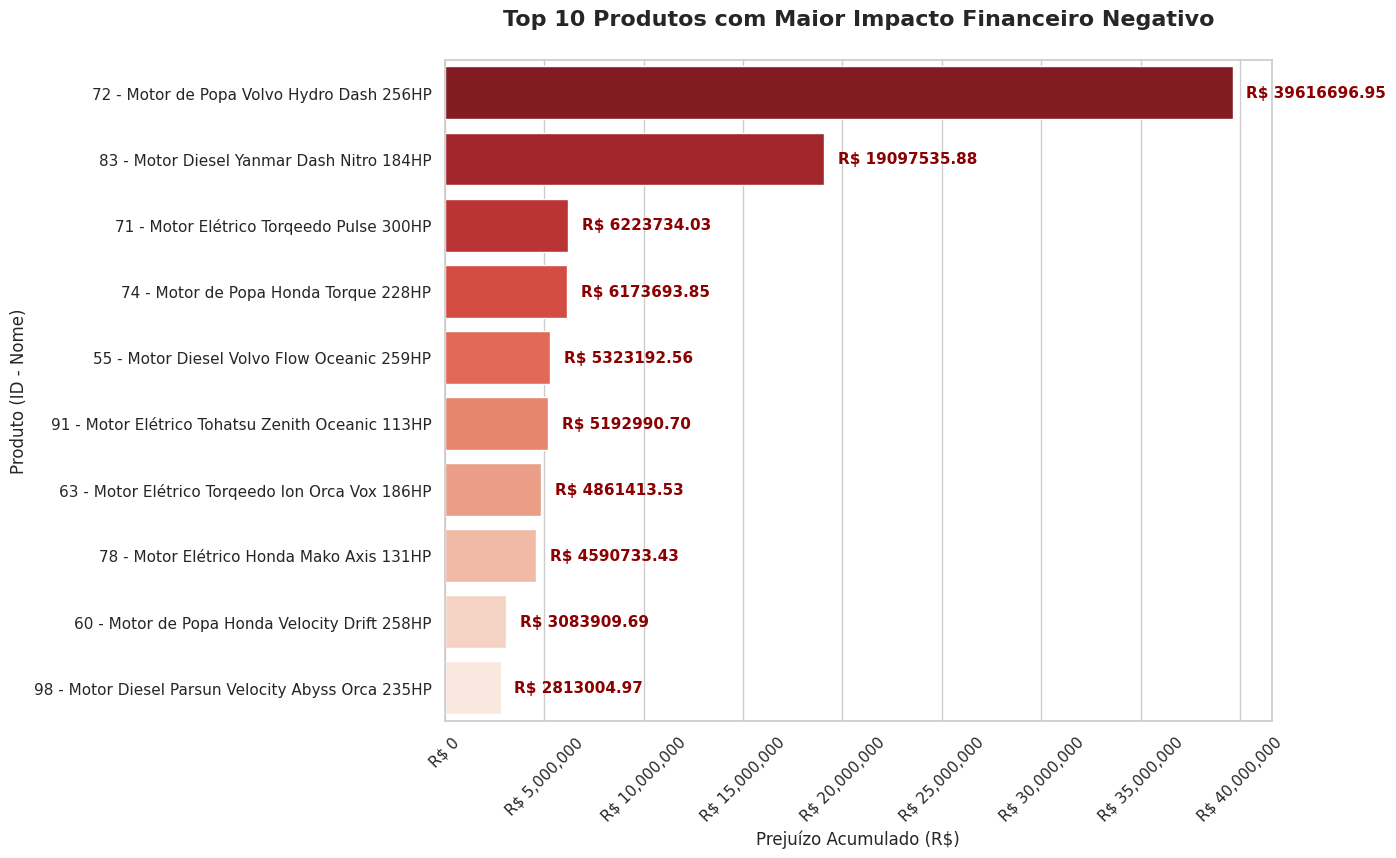

In [278]:

# 1. Buscar os nomes dos produtos para o ranking
df_nomes = produtos[['id_produto', 'nome_produto']].drop_duplicates()

# 2. Cruzar com a sua análise de prejuízo
analise_completa = pd.merge(
    analise_prejuizo.head(10),
    df_nomes,
    on='id_produto',
    how='left'
)

# 3. Criar uma coluna combinada "ID - Nome" para o gráfico não ficar poluído
analise_completa['exibicao'] = analise_completa['id_produto'].astype(str) + " - " + analise_completa['nome_produto']

# 4. Criando o Gráfico Executivo
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

plot = sns.barplot(
    data=analise_completa,
    y='exibicao',
    x='prejuizo_total',
    palette='Reds_r'
)

# Formatação do eixo X em Reais
plot.xaxis.set_major_formatter(ticker.StrMethodFormatter('R$ {x:,.0f}'))

# Títulos e Ajustes
plt.title('Top 10 Produtos com Maior Impacto Financeiro Negativo', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('Prejuízo Acumulado (R$)', fontsize=12)
plt.ylabel('Produto (ID - Nome)', fontsize=12)

# Adicionando os rótulos de valor nas pontas das barras
for i in plot.containers:
    plot.bar_label(i, padding=10, fmt='R$ %.2f', fontsize=11, fontweight='bold', color='darkred')

plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [279]:
# 1. Isolando os dados apenas do Produto 72
# Usar o DataFrame 'resultado' que já possui os totais agregados por id_produto
prod_72_data = resultado[resultado['id_produto'] == 72]

# 2. Obtendo os totais de receita e prejuízo diretamente do DataFrame 'resultado'
# Assumindo que para um id_produto, haverá apenas uma linha no 'resultado' DataFrame
receita_72 = prod_72_data['receita_total'].iloc[0]
prejuizo_72 = prod_72_data['prejuizo_total'].iloc[0]

# 3. Calculando o percentual de perda sobre a receita
percentual_perda = (prejuizo_72 / receita_72) * 100

print(f"--- Análise Crítica: Produto 72 ---")
print(f"Receita Total: R$ {receita_72:,.2f}")
print(f"Prejuízo Acumulado: R$ {prejuizo_72:,.2f}")
print(f"Percentual de Perda: {percentual_perda:.2f}%")

--- Análise Crítica: Produto 72 ---
Receita Total: R$ 63,057,815.65
Prejuízo Acumulado: R$ 39,616,696.95
Percentual de Perda: 62.83%


🔴 Produtos Criticos

A análise revelou produtos com alto percentual de perda, destacando-se o produto 72, com mais de 60% da receita comprometida por prejuízo.

Percentual de Perda (62,83%): Isso significa que para cada R$ 100,00 que entram no caixa, a empresa perde R$ 62,83 %

Pode estar relacionado a falhas no processo de precificação ou ausência de atualização dos custos com base no câmbio, reforçando a necessidade de integração entre dados de vendas e custos em tempo real.





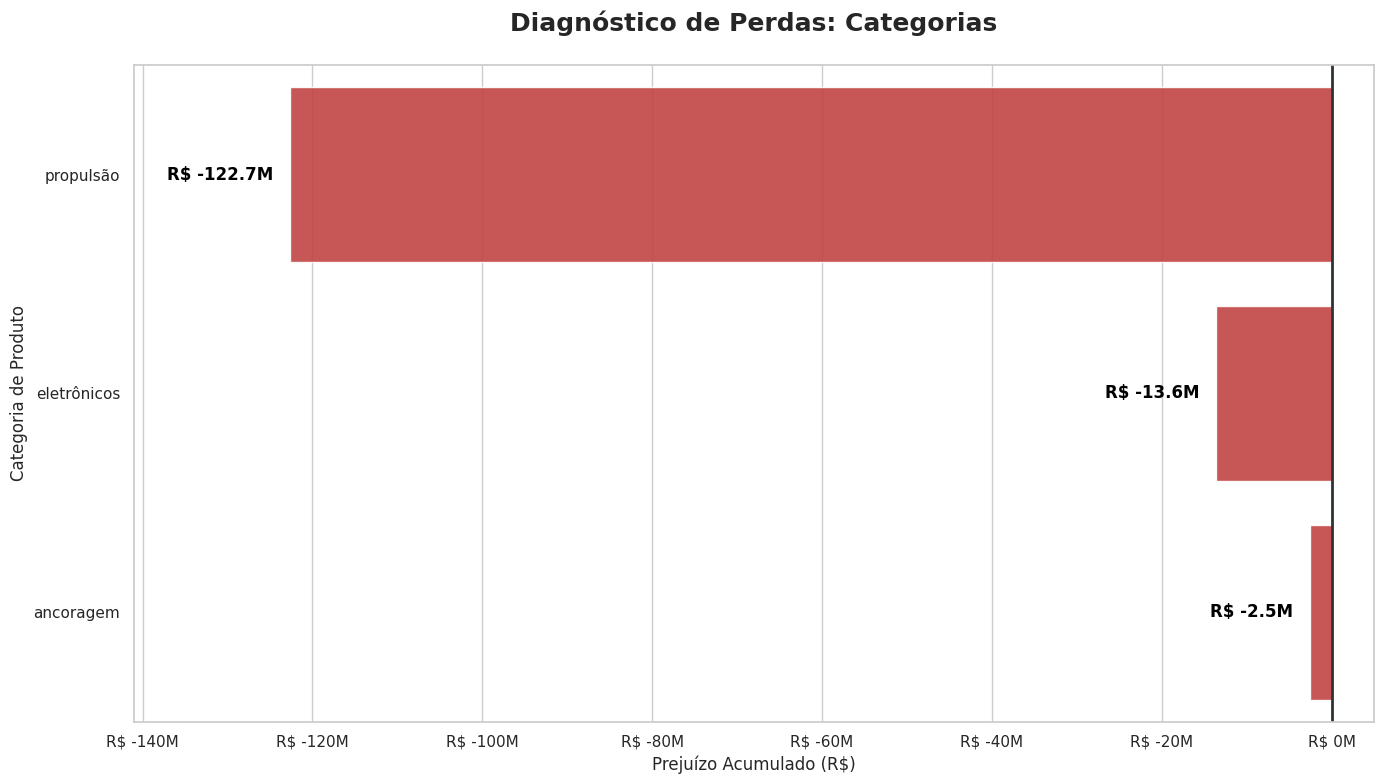

In [284]:
# Gráfico de perdas por categoria

res_categoria = df_merge.groupby('categoria')['prejuizo'].sum().reset_index()
res_categoria = res_categoria.sort_values(by='prejuizo', ascending=True)

# 2. Configuração do Gráfico
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

cor_alerta = '#d63031'

plot = sns.barplot(
    data=res_categoria,
    x='prejuizo',
    y='categoria',
    color=cor_alerta,
    alpha=0.9
)

# 3. Ajustes de Texto e Alinhamento (O NOVO "Pulo do Gato")
plt.title('Diagnóstico de Perdas: Categorias', fontsize=18, pad=25, fontweight='bold')
plt.xlabel('Prejuízo Acumulado (R$)', fontsize=12)
plt.ylabel('Categoria de Produto', fontsize=12)

# Adicionando os rótulos
for i, v in enumerate(res_categoria['prejuizo']):
    # Para valores negativos, o texto deve ficar à ESQUERDA (ha='right') da ponta
    # mas com um deslocamento fixo para não encostar na barra
    plt.text(v - 2e6, i, f'R$ {v/1e6:.1f}M',
             color='black',
             va='center',
             fontweight='bold',
             fontsize=12,
             ha='right') # Garante que o texto fique "antes" da barra terminar à esquerda

# 4. AUMENTAR O LIMITE DO EIXO X (Para o texto de Propulsão não sumir)
# Isso garante um espaço extra à esquerda da barra mais longa
margem_esquerdа = res_categoria['prejuizo'].min() * 1.15
plt.xlim(margem_esquerdа, 5e6) # Vai um pouco além do zero para a direita também

# Formatação do eixo X para Milhões
plot.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x/1e6:.0f}M"))

# Linha de destaque no Zero
plt.axvline(0, color='#2d3436', lw=2)

plt.tight_layout()
plt.show()

In [285]:
# Comparativo simples
total_faturamento = df_merge['valor_total'].sum()
total_custo = df_merge['custo_total_brl'].sum()

print(f"Faturamento Total: R$ {total_faturamento/1e6:.1f}M")
print(f"Custo Total: R$ {total_custo/1e6:.1f}M")
print(f"Resultado Final: R$ {(total_faturamento - total_custo)/1e6:.1f}M")

Faturamento Total: R$ 2610.3M
Custo Total: R$ 2749.0M
Resultado Final: R$ -138.7M



Mesmo com  +2,53% YoY,  o custo para colocar esses produtos no estoque subiu muito mais. Ou seja, a empresa vendeu mas, porém está importando prejuízo. O custo unitário em Reais impulsionado pelo dólar, superou O preço de venda. Hoje, a operação da LH Nautical está escalando o prejuízo em vez do lucro.

A categoria de Propulsão sozinha, é responsável por um prejuízo de R$ 122,7M. Basicamente, cada motor que é vendido, está saindo mais caro para a empresa, do que o valor que recebem dos clientes, isso significa que, se a empresa resolver o problema apenas de Propulsão,já salva a maior parte do caixa da empresa.

# Base de Dados _ Vendas

In [201]:
vendas.head()

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,15-09-2024
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [202]:
vendas.info()
vendas.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   int64  
 1   id_client   9895 non-null   int64  
 2   id_product  9895 non-null   int64  
 3   qtd         9895 non-null   int64  
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   object 
dtypes: float64(1), int64(4), object(1)
memory usage: 464.0+ KB


,id,id_client,id_product,qtd,total
count,9895.000000,9895.000000,9895.000000,9895.000000,9.895000e+03
mean,5000.755533,24.874583,75.255786,8.015260,2.637978e+05
std,2887.000000,14.177715,43.533397,4.301723,3.900072e+05
min,0.000000,1.000000,1.000000,1.000000,2.945000e+02
25%,2501.500000,13.000000,37.000000,4.000000,2.313820e+04
50%,4999.000000,25.000000,74.000000,8.000000,8.222500e+04
75%,7505.500000,37.000000,114.000000,12.000000,3.390945e+05
max,9999.000000,49.000000,150.000000,15.000000,2.222973e+06


In [203]:
# Renomeando as colunas da tabela

vendas = vendas.rename(columns={
    'id': 'id_venda',
    'id_client': 'id_cliente',
    'id_product': 'id_produto',
    'qtd': 'quantidade',
    'total': 'valor_total',
    'sale_date': 'data_venda'
})

In [204]:
# Analisando o total de linhas e de colunas da tabela
vendas.shape

(9895, 6)

In [205]:
# Analisando as colunas da tabela
vendas.columns

Index(['id_venda', 'id_cliente', 'id_produto', 'quantidade', 'valor_total',
       'data_venda'],
      dtype='object')

In [206]:
# Conferindo se consta alguma duplicidade de Id na coluna 'id_client'

clientes_duplicados = (
    vendas['id_cliente']
    .value_counts()
    .loc[lambda x: x > 1]
    .reset_index()
)

clientes_duplicados.columns = ['id_client', 'qtd_ocorrencias']

display(clientes_duplicados)

,id_client,qtd_ocorrencias
0,15,233
1,42,222
2,2,220
3,9,218
4,25,217
5,33,217
6,36,215
7,13,213
8,43,213
9,48,213


*OBS: Os IDs da coluna 'id_client' são consistentes com o comportamento esperado do negócio, pois um mesmo cliente pode realizar múltiplas transações ao longo do tempo. Portanto, a repetição desses identificadores não caracteriza erro, mas sim recorrência de compras.*

In [207]:
# Conferindo se consta alguma duplicidade de Id na coluna 'id_product'

clientes_duplicados = (
    vendas['id_produto']
    .value_counts()
    .loc[lambda x: x > 1]
    .reset_index()
)

clientes_duplicados.columns = ['id_produto', 'qtd_ocorrencias']

display(clientes_duplicados)

,id_produto,qtd_ocorrencias
0,116,88
1,56,85
2,74,85
3,33,83
4,127,83
...,...,...
145,24,47
146,95,47
147,68,47
148,75,45


*OBS: A repetição de IDs de produtos também é esperada, já que um mesmo produto pode ser vendido diversas vezes para diferentes clientes.*

In [208]:
vendas.nunique()

,0
id_venda,9895
id_cliente,49
id_produto,150
quantidade,15
valor_total,3980
data_venda,1446


In [209]:
print("\nIntervalo de datas:")
print("Data mínima:", vendas['data_venda'].min())
print("Data máxima:", vendas['data_venda'].max())


Intervalo de datas:
Data mínima: 01-01-2023
Data máxima: 31-12-2024


In [210]:
print("\nAnálise da coluna de total:")

print("Valor mínimo:", vendas['valor_total'].min())
print("Valor máximo:", vendas['valor_total'].max())
print("Valor médio:", vendas['valor_total'].mean())


Análise da coluna de total:
Valor mínimo: 294.5
Valor máximo: 2222973.0
Valor médio: 263797.8282668015


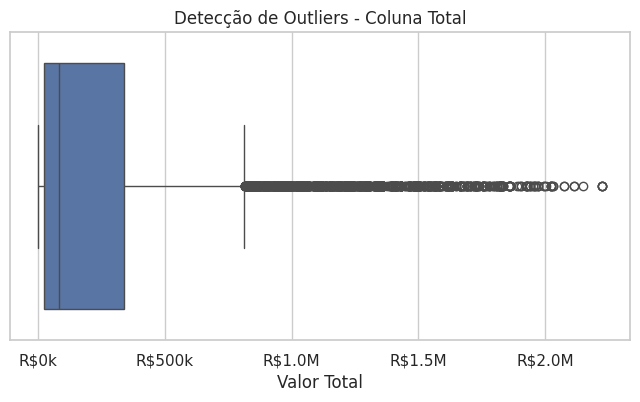

In [211]:
# Detecção de Outlies da coluna 'Total"

plt.figure(figsize=(8,4))
sns.boxplot(x=vendas['valor_total'])

plt.title('Detecção de Outliers - Coluna Total')
plt.xlabel('Valor Total')

# Formata o eixo X para mostrar números reais em vez de 1e6
formatter = ticker.FuncFormatter(lambda x, pos: f'R${x/1e6:,.1f}M' if x >= 1e6 else f'R${x/1e3:,.0f}k')
plt.gca().xaxis.set_major_formatter(formatter)

plt.show()

Foi realizada uma análise gráfica por meio de um boxplot, que evidenciou a presença de outliers na coluna total, com valores significativamente acima da distribuição central, indicando possíveis vendas atípicas.

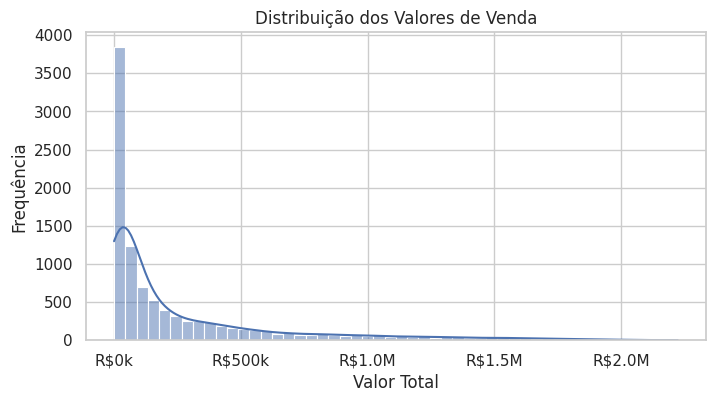

In [212]:
# Gráfico de Histograma para analisar a distribuição dos valores de vendas

plt.figure(figsize=(8,4))
sns.histplot(vendas['valor_total'], bins=50, kde=True)

plt.title('Distribuição dos Valores de Venda')
plt.xlabel('Valor Total')
plt.ylabel('Frequência')

# Formatar o eixo X para mostrar números reais em vez de 1e6
formatter = ticker.FuncFormatter(lambda x, pos: f'R${x/1e6:,.1f}M' if x >= 1e6 else f'R${x/1e3:,.0f}k')
plt.gca().xaxis.set_major_formatter(formatter)
plt.show()

In [213]:
# Detecção estatística de outliers via IQR (Q3 - Q1).

Q1 = vendas['valor_total'].quantile(0.25)
Q3 = vendas['valor_total'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = vendas[(vendas['valor_total'] < limite_inferior) | (vendas['valor_total'] > limite_superior)]

print("Quantidade de outliers indentificados:", len(outliers))

print("1.018 vendas detectadas como fora da curva de normalidade")

Quantidade de outliers indentificados: 1018
1.018 vendas detectadas como fora da curva de normalidade


Analise:

A análise conjunta dos gráficos de histograma e boxplot revelaram que,
o faturamento da empresa segue uma distribuição de "Cauda Longa", onde a vasta maioria das transações concentra-se em tickets baixos, enquanto uma parcela significativa do valor financeiro provém de vendas de altíssimo valor unitário.

O método IQR identificou 1.018 registros como outliers, representados graficamente pela extensa sucessão de pontos que ultrapassam o limite de R$ 800 mil e chegam a superar R$ 2,0 milhões  

In [214]:
(vendas.isnull().sum())

,0
id_venda,0
id_cliente,0
id_produto,0
quantidade,0
valor_total,0
data_venda,0


RESUMO DA BASE DE DADOS - VENDAS_2023_2024

A base de dados da tabela vendas_2023_2024.csv
contém 9.895 registros e 6 variáveis, representando transações realizadas entre 2023 e 2024.

Apesar dos dados estarem completos (sem valores nulos) e apresentarem uma estrutura consistente, foram identificados problemas na coluna de data apresentando múltiplos formatos, e possíveis inconsistências nos valores de venda, que comprometem sua confiabilidade para análises mais profunda,  isso exige tratamento antes de qualquer análise confiável.

Sendo assim, o dataset não está pronto para uso direto em análises avançadas. É necessário realizar um tratamento prévio, especialmente na padronização da coluna de datas e na validação dos valores de vendas.

Em resumo, a empresa já possui dados estruturados, porém ainda carece de padronização e governança, o que limita a confiabilidade para tomada de decisão. Ou seja, a empresa tem dados, mas não tem padronização




TRATAMENTO DA BASE DE DADOS _ TABELA VENDAS





In [215]:
# Formatando a coluna sale_date em tipo data

vendas['data_venda'] = pd.to_datetime(vendas['data_venda'], format='mixed', errors='coerce')

In [216]:
vendas['data_venda'].isna().sum()

np.int64(0)

In [217]:
vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venda     9895 non-null   int64         
 1   id_cliente   9895 non-null   int64         
 2   id_produto   9895 non-null   int64         
 3   quantidade   9895 non-null   int64         
 4   valor_total  9895 non-null   float64       
 5   data_venda   9895 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 464.0 KB


In [218]:
# Criando um dicionário de tradução para os dias da semana

dia_semana = {
    'Monday': 'Segunda-feira',
    'Tuesday': 'Terça-feira',
    'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira',
    'Friday': 'Sexta-feira',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

# Certificando que a coluna 'dia_semana' exista antes do mapeamento
vendas['dia_semana'] = vendas['data_venda'].dt.day_name()

vendas['dia_semana'] = vendas['dia_semana'].map(dia_semana)

In [219]:
# Substituindo vírgula por ponto, caso exista e converter para float

vendas['valor_total'] = vendas['valor_total'].astype(str).str.replace(',', '.').astype(float)
vendas['preco_unitario'] = (vendas['valor_total'] / vendas['quantidade']).astype(float).round(2)

 📊 Análise Exploratória e Visualização de Dados (EDA)


In [220]:
# Extraindo ano, mês, e dia da semana da coluna data_venda

vendas['ano'] = vendas['data_venda'].dt.year
vendas['mes'] = vendas['data_venda'].dt.month
vendas['dia_semana'] = vendas['data_venda'].dt.day_name()

/tmp/ipykernel_16187/3763302609.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=faturamento_anual, x='ano', y='valor_total', palette=cores)


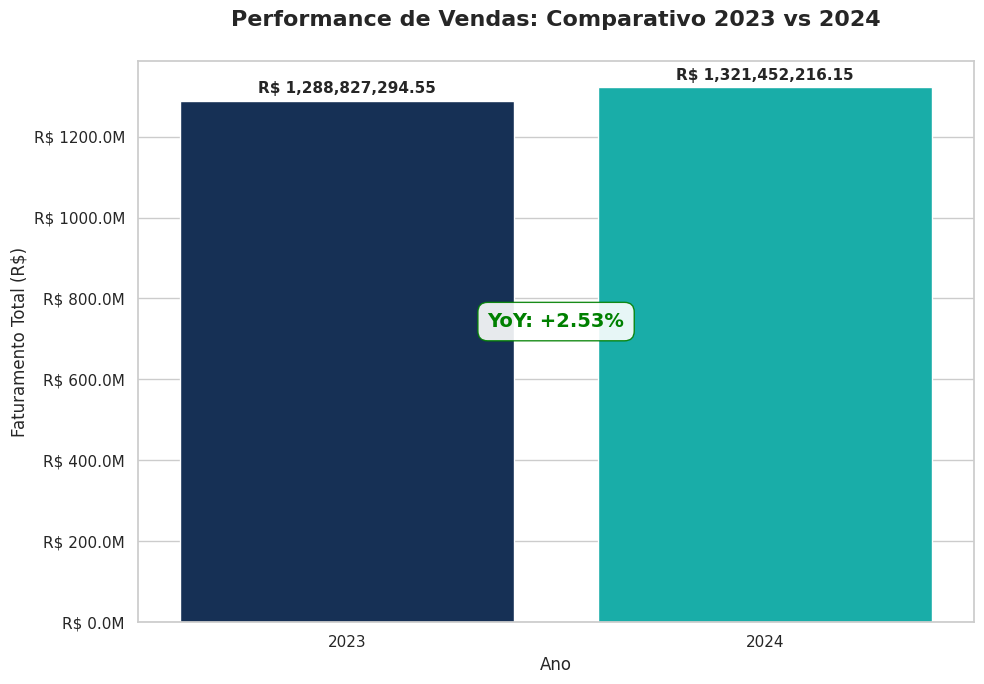

In [221]:
# Gráfico do faturamento total

# Agrupando o faturamento por ano
faturamento_anual = vendas.groupby('ano')['valor_total'].sum().reset_index()

# Calculando o YoY % (Variação Percentual)
# Pegamos o valor de 2024 (índice 1) e comparamos com 2023 (índice 0)
faturamento_2023 = faturamento_anual.iloc[0]['valor_total']
faturamento_2024 = faturamento_anual.iloc[1]['valor_total']
yoy_variacao = ((faturamento_2024 - faturamento_2023) / faturamento_2023) * 100

# Configuração Visual
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
cores = ['#0B2F5F', '#00c6bf']

plot = sns.barplot(data=faturamento_anual, x='ano', y='valor_total', palette=cores)

# Formatação e Títulos
plt.title('Performance de Vendas: Comparativo 2023 vs 2024', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Faturamento Total (R$)', fontsize=12)
plot.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x/1e6:.1f}M"))

# Adicionando os rótulos de valor nas barras
for i in plot.containers:
    plot.bar_label(i, padding=3, fmt='R$ {:,.2f}', fontsize=11, fontweight='bold')

# --- INDICADOR YoY ---
# Definindo a cor do YoY (Verde se cresceu, Vermelho se caiu)
cor_yoy = 'green' if yoy_variacao > 0 else 'red'
simbolo = '+' if yoy_variacao > 0 else ''

# Adicionando o texto do YoY entre as barras
plt.annotate(f'YoY: {simbolo}{yoy_variacao:.2f}%',
             xy=(0.5, max(faturamento_2023, faturamento_2024) * 0.5), # Posição centralizada
             xytext=(0, 20),
             textcoords='offset points',
             ha='center',
             fontsize=14,
             fontweight='bold',
             color=cor_yoy,
             bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=cor_yoy, alpha=0.9))

plt.tight_layout()
plt.show()

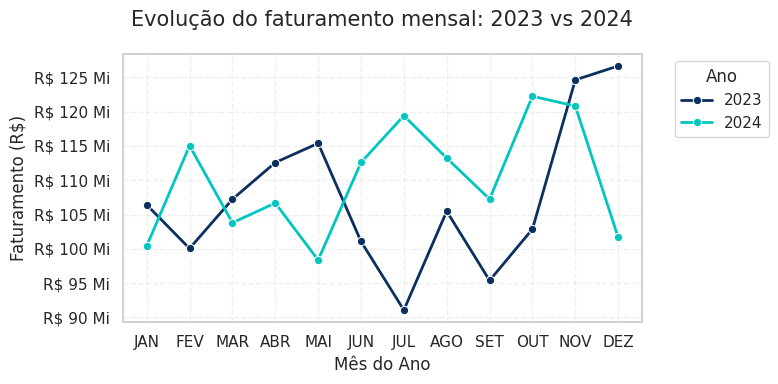

In [222]:
# Gráfico comparativo analisando as vendas de 2023 e 2024

faturamento_mensal = vendas.groupby(['ano', 'mes'])['valor_total'].sum().reset_index()
faturamento_mensal['valor_mi'] = faturamento_mensal['valor_total'] / 1_000_000

plt.figure(figsize=(8, 4))
cores_lh = {2023: "#0B2F5F", 2024: "#00c6bf"}

sns.lineplot(data=faturamento_mensal, x='mes', y='valor_mi', hue='ano',
             marker='o', palette=cores_lh, linewidth=2)

formatter = ticker.FuncFormatter(lambda x, pos: f'R$ {x:,.0f} Mi'.replace(',', '.'))
plt.gca().yaxis.set_major_formatter(formatter)

meses_abr = ['JAN', 'FEV', 'MAR', 'ABR', 'MAI', 'JUN', 'JUL', 'AGO', 'SET', 'OUT', 'NOV', 'DEZ']
plt.xticks(range(1, 13), meses_abr)

plt.xticks(range(1, 13))
plt.title('Evolução do faturamento mensal: 2023 vs 2024', fontsize=15, pad=20)
plt.xlabel('Mês do Ano', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)

plt.legend(title='Ano', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Evolução do Faturamento Mensal: 2023 vs 2024**

Considerando que, a LH Nautical atua no setor náutico, a queda em dezembro de 2024 é um indicador crítico de anomalia. Em um mercado sazonal de verão, este deveria ser o mês de maior faturamento. Esta divergência sugere problemas de ruptura de estoque ou falha na integração de dados entre e-commerce e loja física.

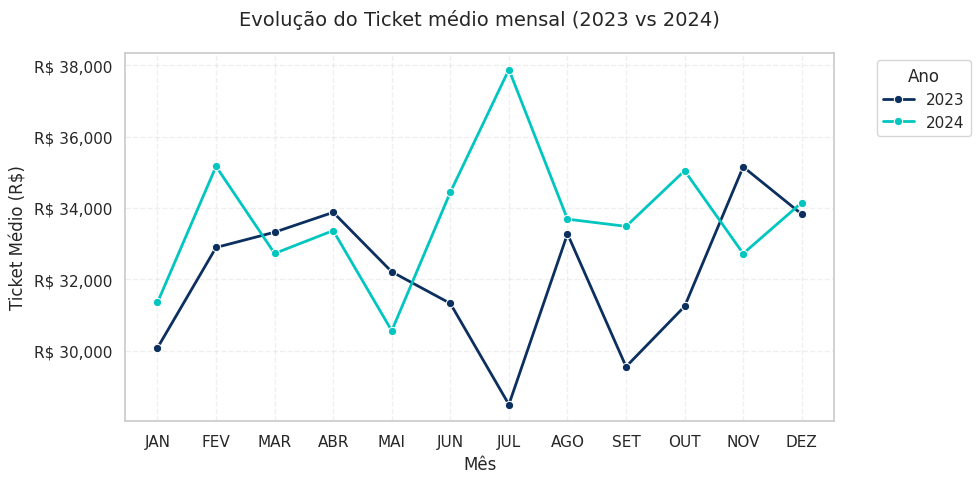

In [223]:
# Gráfico comparativo do Ticket Médio, analisando as vendas de 2023 e 2024

ticket_data = vendas.groupby(['ano', 'mes']).agg({
    'valor_total': 'sum',
    'quantidade': 'sum'
}).reset_index()

ticket_data['ticket_medio'] = ticket_data['valor_total'] / ticket_data['quantidade']


plt.figure(figsize=(10, 5))
cores_lh = {2023: "#0B2F5F", 2024: "#00C6BF"}

sns.lineplot(data=ticket_data, x='mes', y='ticket_medio', hue='ano',
             marker='o', palette=cores_lh, linewidth=2)

formatter = ticker.FuncFormatter(lambda x, pos: f'R$ {x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

meses_abr = ['JAN', 'FEV', 'MAR', 'ABR', 'MAI', 'JUN', 'JUL', 'AGO', 'SET', 'OUT', 'NOV', 'DEZ']

plt.xticks(range(1, 13), meses_abr)
plt.xticks(range(1, 13))
plt.title('Evolução do Ticket médio mensal (2023 vs 2024)', fontsize=14, pad=20)
plt.xlabel('Mês')
plt.ylabel('Ticket Médio (R$)')
plt.legend(title='Ano', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

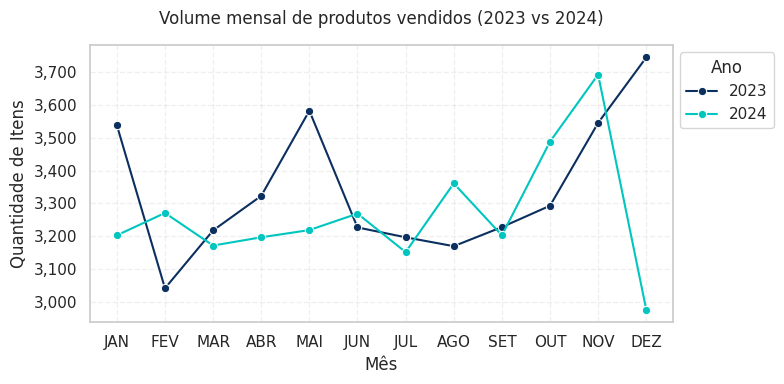

In [224]:
# Gráfico comparativo analisando a quantidade vendida de 2023 e 2024

volume_mensal = vendas.groupby(['ano', 'mes'])['quantidade'].sum().reset_index()
volume_mensal = volume_mensal.sort_values(['ano', 'mes'])

plt.figure(figsize=(8, 4))
cores = {2023: "#0B2F5F", 2024: "#00c6bf"}

sns.lineplot(data=volume_mensal, x='mes', y='quantidade', hue='ano',
             marker='o', palette=cores)

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

meses_abr = ['JAN', 'FEV', 'MAR', 'ABR', 'MAI', 'JUN', 'JUL', 'AGO', 'SET', 'OUT', 'NOV', 'DEZ']
plt.xticks(range(1, 13), meses_abr)

plt.xticks(range(1, 13))
plt.title('Volume mensal de produtos vendidos (2023 vs 2024)', fontsize=12, pad=15)
plt.xlabel('Mês')
plt.ylabel('Quantidade de Itens')
plt.legend(title='Ano', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Análise de Volume: Quantidade de Produtos Vendidos**

O volume de itens vendidos em Dezembro/24 sofreu uma queda brusca, atingindo o patamar mais baixo do biênio (abaixo de 3.000 unidades), contrastando com o pico de Dezembro/23 (mais de 3.700 unidades).

O ponto crítico que identificamos, é que no setor náutico, uma queda simultânea de Faturamento e Volume em pleno mês de dezembro é um forte indicativo de problemas operacionais.

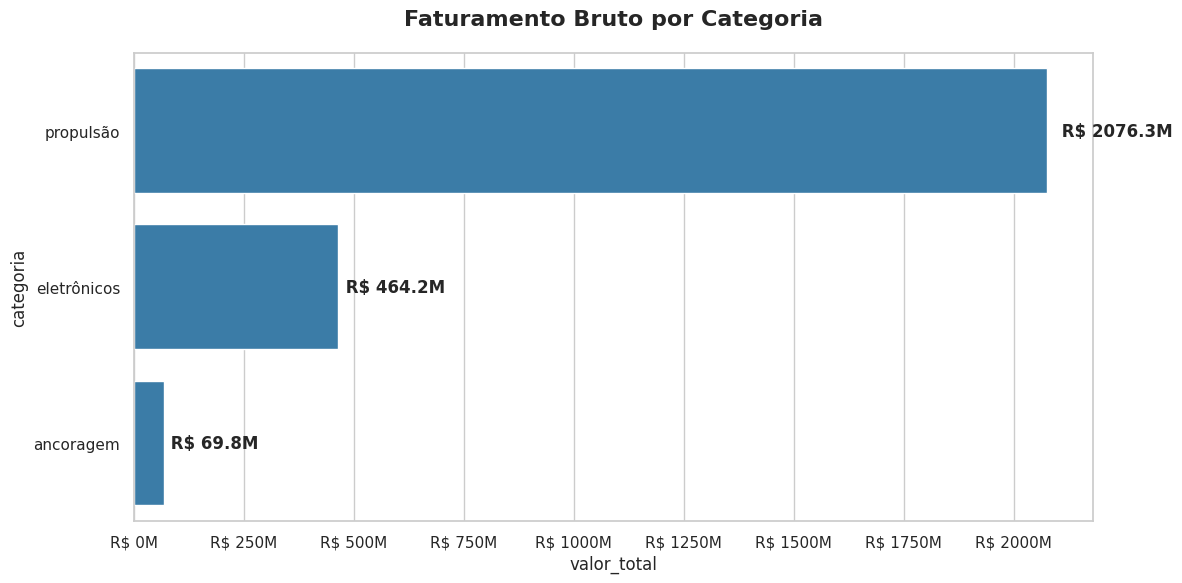

In [287]:
# Gráfico de faturamento por categoria

# Agrupando apenas para o gráfico
vendas_por_cat = df_merge.groupby('categoria')['valor_total'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

plot_vendas = sns.barplot(data=vendas_por_cat, x='valor_total', y='categoria', color='#2980b9')
plt.title('Faturamento Bruto por Categoria', fontsize=16, pad=20, fontweight='bold')
plot_vendas.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x/1e6:.0f}M"))

for i, v in enumerate(vendas_por_cat['valor_total']):
    plt.text(v + (v * 0.01), i, f' R$ {v/1e6:.1f}M', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

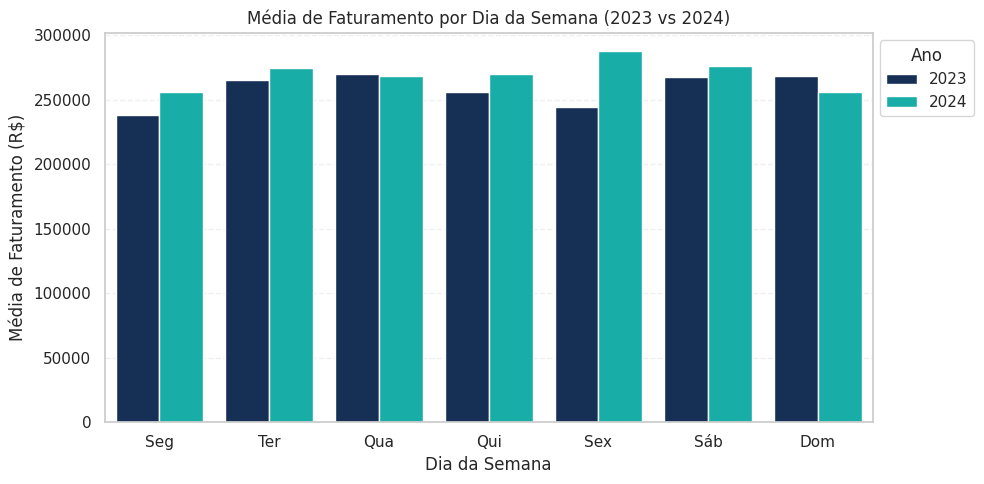

In [288]:
# Gráfico comparativo analisando a média de faturamento por dia da semana, de 2023 e 2024

vendas_dia_ano = vendas.groupby(['ano', 'dia_semana'])['valor_total'].mean().reset_index()

ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cores = {2023: "#0B2F5F", 2024: "#00c6bf"}

plt.figure(figsize=(10, 5))

sns.barplot(data=vendas_dia_ano, x='dia_semana', y='valor_total', hue='ano',
            palette=cores, order=ordem_dias)

plt.xticks(range(7), ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
plt.title('Média de Faturamento por Dia da Semana (2023 vs 2024)', fontsize=12)
plt.ylabel('Média de Faturamento (R$)')
plt.xlabel('Dia da Semana')
plt.legend(title='Ano', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

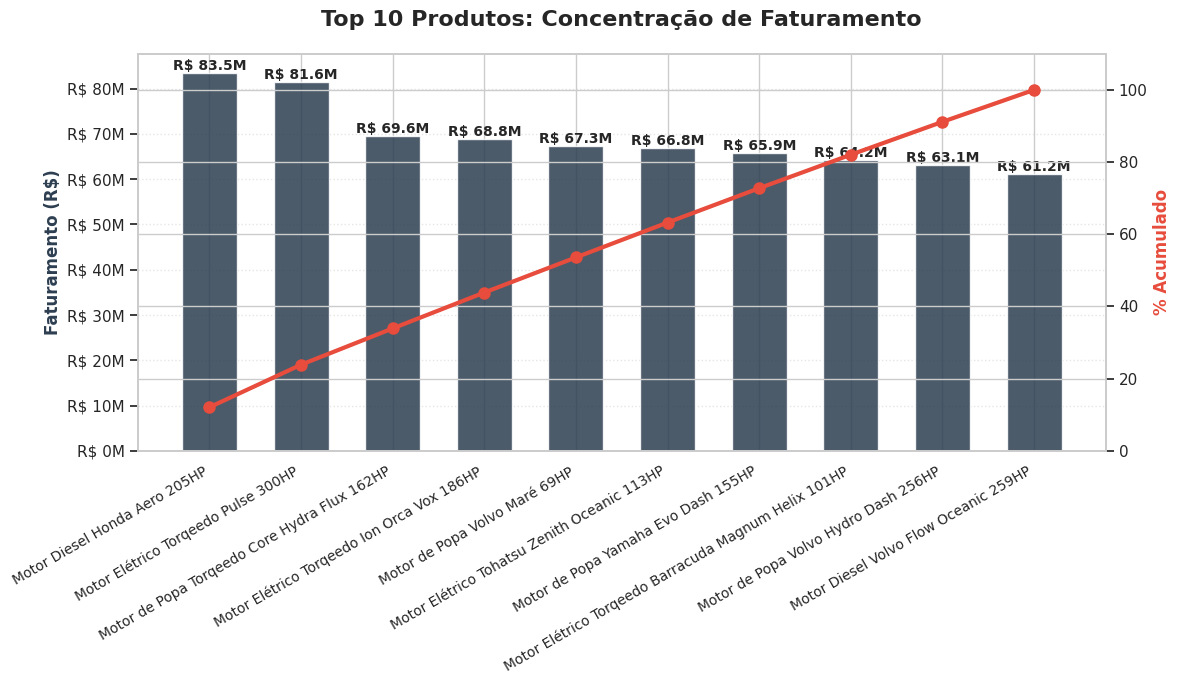

In [289]:
# Grafico de Pareto

# Agrupar e ordenar (Top 10)
df_pareto = df_merge.groupby('nome_produto')['valor_total'].sum().reset_index()
df_pareto = df_pareto.sort_values(by='valor_total', ascending=False).head(10)

# Recalcular o acumulado para o Top 10
# (Nota: O % acumulado aqui será relativo ao faturamento desses 10 produtos)
df_pareto['perc_individual'] = (df_pareto['valor_total'] / df_pareto['valor_total'].sum()) * 100
df_pareto['perc_acumulado'] = df_pareto['perc_individual'].cumsum()

# Gerar o Visual
fig, ax1 = plt.subplots(figsize=(12, 7))

# Barras: Faturamento
color_bar = '#2c3e50'
bars = ax1.bar(df_pareto['nome_produto'], df_pareto['valor_total'], color=color_bar, alpha=0.85, width=0.6)
ax1.set_ylabel('Faturamento (R$)', fontsize=12, fontweight='bold', color=color_bar)

# Linha: % Acumulado
ax2 = ax1.twinx()
color_line = '#e74c3c'
ax2.plot(df_pareto['nome_produto'], df_pareto['perc_acumulado'], color=color_line, marker="o", ms=8, linewidth=3, label='% Acumulado')
ax2.set_ylabel('% Acumulado', fontsize=12, fontweight='bold', color=color_line)

# Formatação Monetária nos eixos e labels
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x/1e6:.0f}M"))
ax2.set_ylim(0, 110)

# Adicionar rótulos de valor no topo das barras (em Milhões)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'R$ {height/1e6:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Top 10 Produtos: Concentração de Faturamento', fontsize=16, pad=20, fontweight='bold')
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# Ajuste fino das etiquetas do eixo X
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

**Análise comparativa semanal: 2023 vs 2024**

Após as analises, percebemos que a LH Nautical teve +2,53% de YoY, com ganho de R$ 32 milhões. Enquanto em 2023 o faturamento era mais distribuído com picos na Terça e Quarta, em 2024 a Sexta-feira disparou como sendo o dia de maior média, superando inclusive o Sábado.

Os 10 principais produtos geram, em média, R$ 60M a R$ 80M cada. Qualquer oscilação nesses itens impacta o faturamento bilionário da empresa. Os 5 primeiros produtos da lista, representam 50% da receita do Top 10. Isso significa que o esforço de venda e logística deve ser prioridade total nesses modelos.

Investigar se, o pico de sexta-feira em 2024 está correlacionado a alguma campanha recorrente de frete grátis ou promoções enviadas via e-mail marketing, visando otimizar a escala logística de despacho de mercadorias.


# Previsão de demanda e Sistema de recomendação

 Data Science and Machine Learning

In [290]:
#  Modelo Baseline


# Filtrar apenas o produto específico
produto = "Motor de Popa Yamaha Evo Dash 155HP"

# Ensure 'nome_produto' and 'id_produto' columns exist for consistency with later code
# This block makes the cell robust to previous rename operations not being run
if 'name' in produtos.columns and 'nome_produto' not in produtos.columns:
    produtos = produtos.rename(columns={'name': 'nome_produto'})
if 'code' in produtos.columns and 'id_produto' not in produtos.columns:
    produtos = produtos.rename(columns={'code': 'id_produto'})


# Get the id_produto from the 'produtos' DataFrame
id_do_produto = produtos[produtos['nome_produto'] == produto]['id_produto'].iloc[0]

# Filter the 'vendas' DataFrame using id_do_produto
df_produto = vendas[vendas['id_produto'] == id_do_produto].copy()

#  Garantir que a data está como datetime e ordenar
df_produto['data_venda'] = pd.to_datetime(df_produto['data_venda'])
df_produto.sort_values('data_venda', inplace=True)

# 3️ Separar treino e teste
treino = df_produto[df_produto['data_venda'] <= '2023-12-31']
teste = df_produto[(df_produto['data_venda'] >= '2024-01-01') & (df_produto['data_venda'] <= '2024-01-31')]

# Criar série temporal diária (preenchendo dias sem vendas com 0)
dias_treino = pd.DataFrame({'data_venda': pd.date_range(treino['data_venda'].min(), treino['data_venda'].max())})
serie_treino = dias_treino.merge(treino[['data_venda','quantidade']], on='data_venda', how='left')
serie_treino['quantidade'] = serie_treino['quantidade'].fillna(0)

# Calcular média móvel de 7 dias (shift=1 para evitar data leakage)
serie_treino['ma_7'] = serie_treino['quantidade'].rolling(7, min_periods=1).mean().shift(1)

# 6Gerar previsão para Janeiro/2024
dias_teste = pd.DataFrame({'data_venda': pd.date_range('2024-01-01','2024-01-31')})
previsao = []

for dia in dias_teste['data_venda']:
    # usar apenas dados até o dia anterior
    dados_anteriores = serie_treino[serie_treino['data_venda'] < dia]
    if len(dados_anteriores) >= 7:
        pred = dados_anteriores['quantidade'].tail(7).mean()
    else:
        pred = dados_anteriores['quantidade'].mean() if len(dados_anteriores) > 0 else 0
    previsao.append(pred)

dias_teste['previsao'] = previsao

# 7️ Se quiser, arredondar previsão para inteiros
dias_teste['previsao'] = dias_teste['previsao'].round().astype(int)

# 8️ Avaliar MAE se tivermos os valores reais
teste_diario = pd.DataFrame({'data_venda': pd.date_range('2024-01-01','2024-01-31')})
teste_diario = teste_diario.merge(teste.groupby('data_venda')['quantidade'].sum().reset_index(),
                                  on='data_venda', how='left')
teste_diario['quantidade'] = teste_diario['quantidade'].fillna(0)

mae = (abs(teste_diario['quantidade'] - dias_teste['previsao'])).mean()

print("Previsão diária Janeiro/2024:")
print(dias_teste.head(7))  # primeiros 7 dias
print("\nMAE do baseline:", round(mae,2))

Previsão diária Janeiro/2024:
  data_venda  previsao
0 2024-01-01         2
1 2024-01-02         2
2 2024-01-03         2
3 2024-01-04         2
4 2024-01-05         2
5 2024-01-06         2
6 2024-01-07         2

MAE do baseline: 2.48


Foi identificou que o modelo de gestão atual (baseado em médias) prevê 2,48 unidades por dia.

In [291]:
# Selecionar os 7 primeiros dias de Janeiro
primeira_semana = dias_teste[dias_teste['data_venda'] <= '2024-01-07']
soma_prev = primeira_semana['previsao'].sum()
print("Soma total previsão 01/01 a 07/01:", soma_prev)

Soma total previsão 01/01 a 07/01: 14


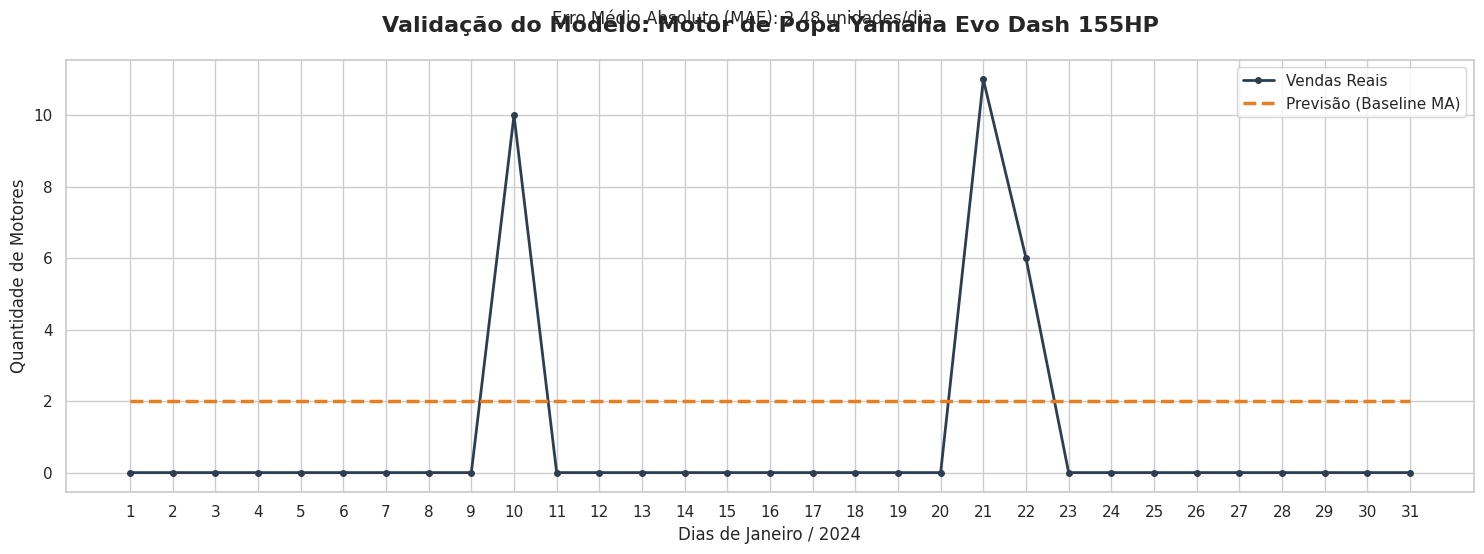

In [292]:
# 📊 Gráfico de Performance: Real vs. Previsto (Janeiro/2024)

# 1. Configuração do ambiente visual
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

# 2. Plotar as Vendas Reais (O que aconteceu de fato)
plt.plot(teste_diario['data_venda'], teste_diario['quantidade'],
         label='Vendas Reais', color='#2c3e50', linewidth=2, marker='o', markersize=4)

# 3. Plotar a Previsão Baseline (Média Móvel)
plt.plot(dias_teste['data_venda'], dias_teste['previsao'],
         label='Previsão (Baseline MA)', color='#e67e22', linestyle='--', linewidth=2.5)

# 4. Títulos e Legendas Executivas
plt.title(f'Validação do Modelo: {produto}', fontsize=16, pad=20, fontweight='bold')
plt.suptitle(f'Erro Médio Absoluto (MAE): {mae:.2f} unidades/dia', fontsize=12, y=0.92)
plt.xlabel('Dias de Janeiro / 2024', fontsize=12)
plt.ylabel('Quantidade de Motores', fontsize=12)

# Ajustar o eixo X para mostrar os dias de 1 a 31
plt.xticks(dias_teste['data_venda'], labels=[d.day for d in dias_teste['data_venda']])

plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

📊 Análise Crítica: Modelo Baseline vs. Realidade de Mercado


Para validar a necessidade de uma Inteligência Preditiva, foi estabelecio um Baseline (Linha de Base) utilizando a média móvel simples. O objetivo é comparar como uma gestão tradicional se comporta diante da volatilidade real da LH Nautical.

Principais Constatações:
Inércia do Modelo (Previsão = 2): O modelo baseline sugere a manutenção de um estoque estático de 2 unidades/dia. No entanto, os dados reais mostram que a empresa opera em picos agressivos, saltando de 0 para 11 unidades em menos de 24 horas.

Erro Médio Absoluto (MAE) de 2.48: O erro médio do modelo (2.48) é superior à própria previsão diária (2.0). Tecnicamente, isso indica que o modelo de média "erra" mais do que tenta prever, tornando-o inviável para o planejamento estratégico.

Impactos Financeiros Identificados:

Ruptura de Estoque: Nos dias de pico (ex: dias 10 e 21), a previsão de 2 unidades resultaria em vendas perdidas, pois a demanda real foi 5x maior que o esperado.
Capital Imobilizado: Nos longos períodos de demanda zero, manter um estoque baseado na média gera custo de armazenagem e trava o fluxo de caixa sem necessidade.

Conclusão: A LH Nautical não possui uma demanda linear. A transição para um modelo de Estoque Dinâmico (Just-in-Time) é mandatória para sincronizar a compra de motores com os picos reais de consumo

In [293]:
# 'Sistema de Recomendação:

# 1️ Construir a matriz Usuário × Produto
# Considera 1 se cliente comprou pelo menos uma vez, 0 caso contrário
matriz = vendas.groupby(['id_cliente', 'id_produto']).size().unstack(fill_value=0)
matriz[matriz > 0] = 1  # converte contagem para 1/0

# 2️ Calcular similaridade de cosseno entre produtos
# Transpor para que cada coluna seja um produto
similaridade = cosine_similarity(matriz.T)
produtos_ids = matriz.columns
df_similaridade = pd.DataFrame(similaridade, index=produtos_ids, columns=produtos_ids)

# 3️ Ranking de produtos similares ao GPS
produto_ref = "GPS Garmin Vortex Maré Drift"
# pegar id_produto do GPS
id_gps = produtos[produtos['nome_produto'] == produto_ref]['id_produto'].iloc[0]

# Ordenar similaridade do produto de referência
ranking = df_similaridade[id_gps].sort_values(ascending=False)
ranking = ranking.drop(id_gps)  # remover o próprio GPS
top_5 = ranking.head(5)

print("Top 5 produtos similares ao GPS Garmin Vortex Maré Drift:")
print(top_5)

Top 5 produtos similares ao GPS Garmin Vortex Maré Drift:
id_produto
94     0.869626
11     0.868037
35     0.853913
115    0.850000
1      0.850000
Name: 27, dtype: float64


Produto com maior similaridade ao “GPS Garmin Vortex Maré Drift”: id_produto = 94
Valor da similaridade de cosseno: 0.8696


O produto com MAIOR similaridade é o ID: 94
Nome do Produto: Motor de Popa Volvo Magnum 276HP
Grau de Similaridade: 0.8696
----------------------------


/tmp/ipykernel_16187/2389472024.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot_rec = sns.barplot(


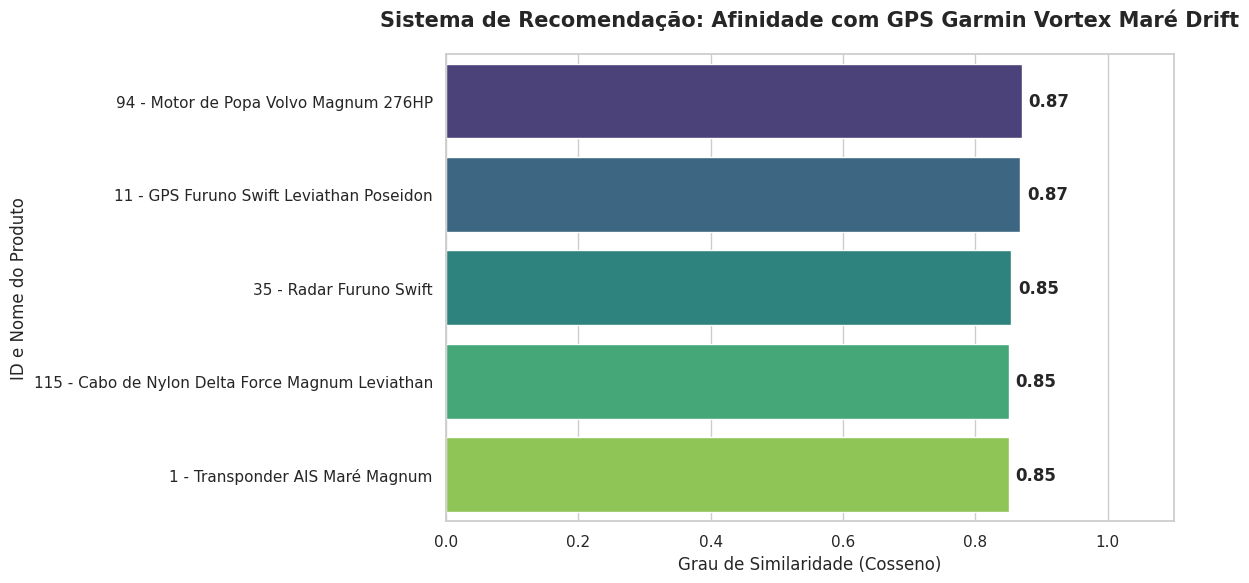

In [294]:
# Gráfico do Sitema de recomendação com o nome do produto

mapa_nomes = dict(zip(produtos['id_produto'], produtos['nome_produto']))
df_top5 = top_5.reset_index()
df_top5.columns = ['id_produto', 'grau_similaridade']
df_top5['nome_produto'] = df_top5['id_produto'].map(mapa_nomes)

# Criar coluna combinada para aparecer no gráfico: "ID - Nome"
df_top5['id_nome'] = df_top5['id_produto'].astype(str) + " - " + df_top5['nome_produto']

# 2. Saída em Texto (Resposta Objetiva para a Questão 8.2)
maior_sim_id = df_top5.iloc[0]['id_produto']
maior_sim_nome = df_top5.iloc[0]['nome_produto']
maior_sim_valor = df_top5.iloc[0]['grau_similaridade']

print(f"O produto com MAIOR similaridade é o ID: {maior_sim_id}")
print(f"Nome do Produto: {maior_sim_nome}")
print(f"Grau de Similaridade: {maior_sim_valor:.4f}")
print("-" * 28)

# 3. Configuração Visual do Gráfico
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

plot_rec = sns.barplot(
    data=df_top5,
    x='grau_similaridade',
    y='id_nome',  # Agora usamos a coluna que tem o ID e o Nome
    palette='viridis'
)

plt.title(f'Sistema de Recomendação: Afinidade com {produto_ref}',
          fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Grau de Similaridade (Cosseno)', fontsize=12)
plt.ylabel('ID e Nome do Produto', fontsize=12)

# Adicionar os valores exatos nas barras
for i, v in enumerate(df_top5['grau_similaridade']):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')

plt.xlim(0, 1.1)
plt.tight_layout()
plt.show()

### 🧠 Inteligência de Cross-Selling: Motor de Recomendação por Similaridade

Para potencializar o faturamento da **LH Nautical**, foi implementado um sistema de recomendação baseado no algoritmo de **Similaridade de Cosseno**. Esta técnica permite identificar quais produtos "combinam" entre si com base no comportamento histórico de compra dos clientes de elite.


* **Aumento do LTV (Lifetime Value):** Ao sugerir o produto certo no momento certo, aumentamos o tempo de vida e o valor gasto pelo cliente na empresa.
* **Redução de Estoque Parado:** Podemos usar a recomendação para sugerir itens complementares que estão com saída lenta, mas que possuem alta similaridade com os "best-sellers".
* **Venda Consultiva:** A equipe de vendas deixa de "chutar" ofertas e passa a oferecer soluções baseadas em dados reais de comportamento.

> **Conclusão Técnica:** O uso da Similaridade de Cosseno supera filtros simples de categoria, pois entende a **complementaridade** dos itens. É a transição de uma loja que "espera o cliente pedir" para uma plataforma que "antecipa o desejo do navegador".

# Bases_tratadas para Download

In [295]:
# Base cliente_tratado

from google.colab import files
clientes.to_csv('clientes_tratados.csv', index=False, encoding='utf-8-sig')
files.download('clientes_tratados.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [296]:
custos_final.to_csv (
    'custos_tratados_final.csv' ,
  sep=';' ,
  index=False,
  decimal=',' ,
  encoding='utf-8-sig'
)
from google.colab import files
files.download('custos_tratados_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [297]:
# Base produtos_tratado
from google.colab import files
produtos.to_csv('produtos_tratados.csv', index=False, sep=';', encoding='utf-8-sig')
files.download('/content/produtos_tratados.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [298]:
# Base vendas_tratado
from google.colab import files
vendas.to_csv('vendas_tratados_2023-2024.csv', sep=';', index=False, decimal=',', encoding='utf-8-sig')
files.download('vendas_tratados_2023-2024.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>